<a href="https://colab.research.google.com/github/vsaengerderache/scour_ai/blob/main/scour_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import this

In [ ]:
!pip install ipytest
!pip install scikit-optimize
import ipytest
import pytest

ipytest.autoconfig()

In [ ]:
# import library

from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
import geopandas as gpd
import seaborn as sns
from pprint import pprint
import math
import pytest

In [ ]:
# connect to drive
drive.mount('/content/drive')

# path to working directory
%cd '/content/drive/My Drive/shared_folder_scour_ai//datos'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/shared_folder_scour_ai/datos


# Data exploration


Upload dataset, processing, detect outliers

In [ ]:
!ls # show files in folder

 01_DATA.xlsx		     '2009_ Lee_y_Sturm.xlsx'
 1980_Jain_y_fischer.xlsx     2013_Lanca_et_al.xlsx
 1982_Chee.xlsx		      data_processed
 1982_zanke.xls		      data_run
 1984_Chiew.xlsx	      Datos_supercriticos.xlsx
 1995_Dey_et_al.xls	      Pier_Shape.xlsx
 2001_Ting_et_al.xls	      plot
 2001_Yammaz.xls	      results
 2005_Mueller_y_Wagner.xlsx


In [ ]:
# read dataset
df = pd.read_excel('01_DATA.xlsx')
df = df.iloc[1:].reset_index(drop=True) # delete first row
df = df.rename(columns={ # rename columns
    'id': 'id',
    'Autor': 'author',
    'Denominacion original': 'original denomination',
    'scour depth (m)': 'ymax',
    'pier diameter (m)': 'b',
    'flow depth (m)': 'h',
    'flow velocity (m/s)': 'v',
    'D50 (mm)': 'd50',
    'H/b': 'h/b',
    'b/D50': 'b/d50'
})
 # create id col
df['id'] = range(1, len(df) + 1)
df = df[['id'] + [col for col in df.columns if col != 'id']]

# replace - and 999 by NA
df = df.where(~df.isin(['-', 999]), pd.NA)

# put _ in the col names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

 # convert columns to numeric where possible
numeric_cols = ['ymax', 'b', 'h', 'v', 'd50', 'sigma', 'skew', 'ds/b', 'b/d50']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# convert pier shape to lowercase
df['pier_shape'] = df['pier_shape'].astype(str).str.lower()

display(df) # display
print(df.dtypes) # types

,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),ro,sigma,pier_shape,skew,ds/b,h/b,b/d50,fr
0,1.0,1.0,Jain and Fischer (1981),F-2,0.09900,0.0508,0.102,0.75,0.25,0.00025,1.65,1.34,cylindrical,0,1.948819,2.007874,203.200000,0.749768
1,2.0,2.0,Jain and Fischer (1981),F-3,0.11400,0.0508,0.102,1.00,0.25,0.00025,1.65,1.34,cylindrical,0,2.244094,2.007874,203.200000,0.999690
2,3.0,3.0,Jain and Fischer (1981),F-4,0.15700,0.0508,0.102,1.20,0.25,0.00025,1.65,1.34,cylindrical,0,3.090551,2.007874,203.200000,1.199628
3,4.0,4.0,Jain and Fischer (1981),M-1,0.08600,0.0508,0.102,0.50,1.50,0.00150,1.65,1.25,cylindrical,0,1.692913,2.007874,33.866667,0.499845
4,5.0,5.0,Jain and Fischer (1981),M-2,0.08700,0.0508,0.102,0.65,1.50,0.00150,1.65,1.25,cylindrical,0,1.712598,2.007874,33.866667,0.649799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,1026.0,1222.0,Chiew (1984),A5-02,0.09855,0.0450,0.240,1.43,0.85,0.00085,1.65,1.23,cylindrical,0,2.190000,5.333333,52.941176,0.931957
1026,1027.0,1223.0,Chiew (1984),A5-03,0.09540,0.0450,0.240,1.21,0.85,0.00085,1.65,1.23,cylindrical,0,2.120000,5.333333,52.941176,0.788579
1027,1028.0,1224.0,Chiew (1984),A5-04,0.09855,0.0450,0.240,1.46,0.85,0.00085,1.65,1.23,cylindrical,0,2.190000,5.333333,52.941176,0.951509
1028,1029.0,1225.0,Chiew (1984),A5-05,0.09630,0.0450,0.340,1.39,0.85,0.00085,1.65,1.23,cylindrical,0,2.140000,7.555556,52.941176,0.761098


id                       float64
unnamed:_0               float64
author                    object
original_denomination     object
ymax                     float64
b                        float64
h                        float64
v                        float64
d50                      float64
d50_(m)                  float64
ro                       float64
sigma                    float64
pier_shape                object
skew                       int64
ds/b                     float64
h/b                      float64
b/d50                    float64
fr                       float64
dtype: object


In [ ]:
df_zero_velocity = df[df['v'] == 0]
print(df_zero_velocity)
df = df[df['v'] != 0].copy()

Empty DataFrame
Columns: [id, unnamed:_0, author, original_denomination, ymax, b, h, v, d50, d50_(m), ro, sigma, pier_shape, skew, ds/b, h/b, b/d50, fr]
Index: []


* ymax (m) (scour depth max)
* b (m) (pier diameter)
* h (m) (flow depth)
* v (m/s) (flow velocity)
* d50 (mm) (particle diameter)
* sigma (geometric standard deviation)

In [ ]:
print(df.isna().sum())

id                       1
unnamed:_0               1
author                   0
original_denomination    0
ymax                     0
b                        0
h                        0
v                        0
d50                      0
d50_(m)                  0
ro                       0
sigma                    0
pier_shape               0
skew                     0
ds/b                     0
h/b                      0
b/d50                    0
fr                       0
dtype: int64


In [ ]:
df.dropna(subset=['ymax'], inplace=True)

In [ ]:
df.dropna(subset=['d50'], inplace=True)
print(df.isna().sum())

id                       1
unnamed:_0               1
author                   0
original_denomination    0
ymax                     0
b                        0
h                        0
v                        0
d50                      0
d50_(m)                  0
ro                       0
sigma                    0
pier_shape               0
skew                     0
ds/b                     0
h/b                      0
b/d50                    0
fr                       0
dtype: int64


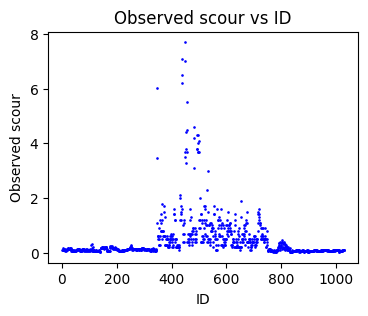

In [ ]:
# plot observed scour vs id
plt.figure(figsize=(4, 3))
df = df.dropna(subset=['id', 'ymax'])
plt.scatter(df['id'], df['ymax'], color='b', s=0.8)
plt.xlabel('ID')
plt.ylabel('Observed scour')
plt.title('Observed scour vs ID')
plt.show()

In [ ]:
# Detect duplicates
duplicates = df[df.duplicated()]

# check if there are any duplicates
if not duplicates.empty:
    print('Warning: Duplicate values found in the dataset')
    display(duplicates)
else:
    print('No duplicate values found in the dataset')

No duplicate values found in the dataset


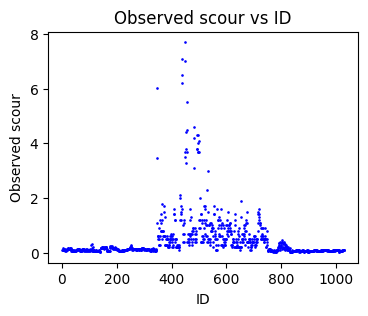

In [ ]:
# Delete outliers
#df = df[~df['ymax'].isin(df['ymax'].nlargest(2))]  # delete two largest values

# observed scour vs id
plt.figure(figsize=(4, 3))
plt.scatter(df['id'], df['ymax'], color='b', s=0.8)
plt.xlabel('ID')
plt.ylabel('Observed scour')
plt.title('Observed scour vs ID')
plt.show()

In [ ]:
df['pier_shape'] = (
    df['pier_shape']
    .str.strip()
    .str.lower()
    .replace({
        'cylindrical': 'circular',
        'round': 'circular',
        'square': 'rectangular'
    })
)
print(df['pier_shape'].unique())

['circular' 'sharp' 'rectangular']


# Calculation with traditional scour formulas

Calculate for each observation in the dataset the scour values preditect by the equations provided



In [ ]:
df = df.copy()

g = 9.81  # gravity acceleration (m/s^2)
density_solid = 2650
density_water = 1000
delta = 1.65  # relative density: (solid density - water density) / water density
nu = 0.000001  # kinematic viscosity (m2/s)

df['g'] = g
df['density_solid'] = density_solid
df['density_water'] = density_water
df['delta'] = (df['density_solid']-df['density_water']) / df['density_water']
df['density_t_m3'] = df['ro']+1
df['nu'] = nu

In [ ]:
df['w'] = 11 / df['d50'] * nu * (df['b']**3 * 0.01 + 1)**0.5 - 1
df['fr'] = df['v'] / (df['g'] * df['h'])**0.5
df['b_d50'] = df['b'] / df['d50']
df['h_b'] = df['h'] / df['b']
df['obs_dimensionless'] = df['ymax'] / df['b']
df['b/h'] = df['b'] / df['h']

In [ ]:
# vcr estimated to Neill 1973
def calculate_vcr_n(d50, h):
    d50=d50/1000

    if d50 < 0.0009:
        theta_s = 0.0019 * d50**(-0.384)
    elif 0.0009 <= d50 <= 0.020:
        theta_s = 0.0942 * d50**(0.175)
    else:
        theta_s = 0.047

    vcr_n = (theta_s)**0.5 * 31.08 * h**(1/6) * d50**(1/3)
    return vcr_n

In [ ]:
# vcr estimated from Shields 1936
def calculate_vcr_shields(d50, h):
  """
  References:
    https://doi.org/10.1061/(ASCE)HY.1943-7900.0000800
    https://drive.google.com/file/d/1Bt9rjmcilpVrn8minHE_v-1iR984_Raz/view

  """
  v_c = np.nan

  y_1 = h
  d50 = d50 / 1000
  # Eq. (11)
  u_asterisk = (16.2*d50*((9.09*10**(-6)/d50)-d50*(38.76+9.6*np.log(d50))-0.005))**0.5
  # Eq. (12)
  r = u_asterisk * d50 / (2.32*10**(-7))

  if 5 <= r and r <= 70:
    v_c = 2.5 * u_asterisk * np.log(73.5*y_1/(d50*(r*(2.85-0.58*np.log(r)+0.002*r)+111/r-6)))
  elif r > 70:
    v_c = 2.5 * u_asterisk * np.log(2.21*y_1/d50)
  elif r < 5:
    v_c = np.nan

  return(v_c)

In [ ]:
# vcr estimated from Zanke 198-
def calculate_vcr_zanke(d50, g, delta, nu):
    d50_m = d50 / 1000  # convert d50 to m
    vcr = 1.4 * (2 * (g * delta * d50_m) ** 0.5 + 10.5 * nu / d50_m)
    return vcr

In [ ]:
# vcr estimated from Zhang et al. 198
def calculate_vcr_zhang(d_o, d, p_s, p):
  """
  References:
    CEL: https://rosap.ntl.bts.gov/view/dot/855

  Args:
    d_o: normal depth
    d: average diameter of bed material
    p_s: density of sediment particles
    p: density of water

  Return:
    v_c: critical velocity
  """
  # Eq. (2)
  v_c = ((d_o/d)**0.14) * (17.6*(p_s-p)/p*d+0.00000605*((10+d_o)/(d**0.72)))**0.5

  return(v_c)

In [ ]:
# apply functions vcr to df
df['vcr_neill'] = df.apply(lambda row: calculate_vcr_n(row['d50'], row['h']), axis=1)
df['vcr_shields'] = df.apply(lambda row: calculate_vcr_shields(row['d50'], row['h']), axis=1)
df['vcr_zanke'] = df.apply(lambda row: calculate_vcr_zanke(row['d50'], row['g'], row['delta'], row['nu']), axis=1)
df['vcr_zhang'] = df.apply(lambda row: calculate_vcr_zhang(row['h'], row['d50']/1000, row['density_solid'], row['density_water']), axis=1)
# other
df['v_vcr_n']= df['v'] / df['vcr_neill']
df['v_vcr']= df['v'] / df['vcr_zanke']

display(df)

/tmp/ipython-input-374952169.py:14: RuntimeWarning: invalid value encountered in scalar power
  u_asterisk = (16.2*d50*((9.09*10**(-6)/d50)-d50*(38.76+9.6*np.log(d50))-0.005))**0.5


,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),...,b_d50,h_b,obs_dimensionless,b/h,vcr_neill,vcr_shields,vcr_zanke,vcr_zhang,v_vcr_n,v_vcr
0,1.0,1.0,Jain and Fischer (1981),F-2,0.09900,0.0508,0.102,0.75,0.25,0.00025,...,0.203200,2.007874,1.948819,0.498039,0.286770,0.235979,0.236917,0.409987,2.615338,3.165670
1,2.0,2.0,Jain and Fischer (1981),F-3,0.11400,0.0508,0.102,1.00,0.25,0.00025,...,0.203200,2.007874,2.244094,0.498039,0.286770,0.235979,0.236917,0.409987,3.487118,4.220894
2,3.0,3.0,Jain and Fischer (1981),F-4,0.15700,0.0508,0.102,1.20,0.25,0.00025,...,0.203200,2.007874,3.090551,0.498039,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073
3,4.0,4.0,Jain and Fischer (1981),M-1,0.08600,0.0508,0.102,0.50,1.50,0.00150,...,0.033867,2.007874,1.692913,0.498039,0.422550,0.373473,0.446095,0.404314,1.183292,1.120838
4,5.0,5.0,Jain and Fischer (1981),M-2,0.08700,0.0508,0.102,0.65,1.50,0.00150,...,0.033867,2.007874,1.712598,0.498039,0.422550,0.373473,0.446095,0.404314,1.538279,1.457089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,1026.0,1222.0,Chiew (1984),A5-02,0.09855,0.0450,0.240,1.43,0.85,0.00085,...,0.052941,5.333333,2.190000,0.187500,0.393173,0.329433,0.345725,0.410762,3.637071,4.136236
1026,1027.0,1223.0,Chiew (1984),A5-03,0.09540,0.0450,0.240,1.21,0.85,0.00085,...,0.052941,5.333333,2.120000,0.187500,0.393173,0.329433,0.345725,0.410762,3.077522,3.499892
1027,1028.0,1224.0,Chiew (1984),A5-04,0.09855,0.0450,0.240,1.46,0.85,0.00085,...,0.052941,5.333333,2.190000,0.187500,0.393173,0.329433,0.345725,0.410762,3.713373,4.223010
1028,1029.0,1225.0,Chiew (1984),A5-05,0.09630,0.0450,0.340,1.39,0.85,0.00085,...,0.052941,7.555556,2.140000,0.132353,0.416673,0.347261,0.345725,0.431898,3.335948,4.020537


In [ ]:
df['h/vcr'] = df['h'] / df['vcr_zanke']

In [ ]:
def meters_to_feet(m):
    return m * 3.28084

def feet_to_meters(ft):
    return ft / 3.28084

In [ ]:
def cal_2003_van_rijn_v_lp(d50, d90, h, p=1000, p_s=2650, g=9.81, nu=1e-6):
    """
    Calculated live-bed peak velocity from van Rijn 1993, pp. 5.3 and 5.4

    Args:
    - d50: median particle size
    - d90: particle size at 90% finer
    - h: mean water depth
    - p: fluid density
    - p_s: sediment density
    - g: gravedad (m/s²)
    - nu: fluid viscocity

    Return:
    - v_lp: live-bed peak velocity
    """

    s = p_s / p
    d_astersik = ((s - 1) * g / nu**2)**(1/3) * d50

    # Eq. (4.1.11)
    if 1 < d_astersik <= 4:
        theta_cr = 0.24 * d_astersik**-1
    elif 4 < d_astersik <= 10:
        theta_cr = 0.14 * d_astersik**-0.64
    elif 10 < d_astersik <= 20:
        theta_cr = 0.04 * d_astersik**-0.1
    elif 20 < d_astersik <= 150:
        theta_cr = 0.013 * d_astersik**0.29
    elif d_astersik > 150:
        theta_cr = 0.055
    else:
        return np.nan

    t_bcr = theta_cr * ((p_s - p) * g * d50)

    v_lp = 0.001  # velocity initial
    while v_lp < 10:
        c_prime = 18 * np.log10((12 * h) / (3 * d90))
        t_bc = p * g * (v_lp / c_prime)**2
        t = (t_bc - t_bcr) / t_bcr
        fr = v_lp / np.sqrt(g * h)

        if fr >= 0.8 and t >= 25:
            return v_lp
        v_lp += 0.001  # velocity increment

    return np.nan

In [ ]:
%%ipytest

"""
Examples Table 1 - https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
"""

@pytest.mark.parametrize('d50, d90, h, expected', [
    (0.27/1000, 0.27/1000*1.5, 0.42, 1.61),
    (0.27/1000, 0.27/1000*1.5, 0.40, 1.58),
])
def test_cal_2003_van_rijn_v_lp(d50, d90, h, expected):
    result = cal_2003_van_rijn_v_lp(d50=d50, d90=d90, h=h)
    assert pytest.approx(result, rel=0.01) == expected

..                                                                                           [100%]
2 passed in 0.07s


In [ ]:
df['d50/h'] = df['d50'] / df['h']

##### Separate dataset: sub-critic and super-critic

In [ ]:
# Separate dataset: sub-critic and super-critic
df_subcritic = df[df['fr'] <= 1].copy()
df_supercritic = df[df['fr'] > 1].copy()

print(f'Subcritical dataset: {len(df_subcritic)} observations')
print(f'Supercritical dataset: {len(df_supercritic)} observations')

Subcritical dataset: 938 observations
Supercritical dataset: 91 observations


In [ ]:
# Export
df_subcritic.to_csv('data_processed/df_subcritic.csv', index=False)
df_supercritic.to_csv('data_processed/df_supercritic.csv', index=False)

## Equations functions

###### 1909 Santa María

In [ ]:
def eq_1909_santa_maria(h, u_s, u_asterisk_c):
  """ Calculate maximum scour depth at a pier
  Sources:
    CEL: https://doi.org/10.1061/JHEND8.HYENG-14216
    DEV: https://doi.org/10.1061/JHEND8.HYENG-14216

  Args:
    h: flow depth
    u_s: flow velocity
    u_asterisk_c: critical shear velocity for inception of sediment

  Return:
    d_s: maximum scour depth

  """
  d_s = h * ((0.65 * u_s - u_asterisk_c) / (u_s - 0.65 * u_s))

  if (0.65 * u_s - u_asterisk_c) <= 0:
    d_s = 0

  return d_s

In [ ]:
%%ipytest

"""
Table 3
"""
@pytest.mark.parametrize('h, u_s, u_asterisk_c, expected', [
    (3.4, 6.0, 1.8, 3.40),
    (3.5, 7.0, 1.8, 3.93),
    (4.0, 8.0, 1.8, 4.86),
    (4.2, 7.0, 1.8, 4.71),
    (5.0, 7.3, 1.8, 5.76),
    #(6.0, 8.0, 1.8, 6.80),
    #(7.0, 9.0, 1.8, 8.36),
    #(6.0, 8.0, 1.5, 7.27),
    #(4.0, 3.54, 0.25, 5.79),
    #(4.0, 8.53, 0.25, 6.21),
    (5.0, 10.0, 1.6, 7.00),
    (4.0, 10.0, 1.85, 5.31),
    #(4.0, 2.31, 0.3, 5.20),
    (4.0, 8.5, 1.4, 5.55),
])

def test_eq_1901_santa_maria(h, u_s, u_asterisk_c, expected):
    result = eq_1901_santa_maria(h, u_s, u_asterisk_c)
    assert pytest.approx(result, rel=0.001) == expected

FFFFFFFF                                                                                     [100%]
============================================= FAILURES =============================================
____________________________ test_eq_1901_santa_maria[3.4-6.0-1.8-3.4] _____________________________

h = 3.4, u_s = 6.0, u_asterisk_c = 1.8, expected = 3.4

    @pytest.mark.parametrize('h, u_s, u_asterisk_c, expected', [
        (3.4, 6.0, 1.8, 3.40),
        (3.5, 7.0, 1.8, 3.93),
        (4.0, 8.0, 1.8, 4.86),
        (4.2, 7.0, 1.8, 4.71),
        (5.0, 7.3, 1.8, 5.76),
        #(6.0, 8.0, 1.8, 6.80),
        #(7.0, 9.0, 1.8, 8.36),
        #(6.0, 8.0, 1.5, 7.27),
        #(4.0, 3.54, 0.25, 5.79),
        #(4.0, 8.53, 0.25, 6.21),
        (5.0, 10.0, 1.6, 7.00),
        (4.0, 10.0, 1.85, 5.31),
        #(4.0, 2.31, 0.3, 5.20),
        (4.0, 8.5, 1.4, 5.55),
    ])
    
    def test_eq_1901_santa_maria(h, u_s, u_asterisk_c, expected):
>       result = eq_1901_santa_maria(h, u_s, u_ast

###### 1949 Inglis

In [ ]:
def eq_1949_inglis(h, b, fr):
  """
  Source:
    CEL: https://www.researchgate.net/publication/341323092_Validation_of_Bridge_Pier_and_Abutment_Scour_Equations

    CEL: https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=6da62afb7e9820afd6fad5c3a8a0c93c4e2c4364

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth
    fr: froude number

  Returns:
    d_s: scour depth
  """

  d_s = (4.2 * (h/b)**0.78 * fr**0.52) * b

  return d_s

###### 1949 Inglis - Poona I (Inglis, 1949)

In [ ]:
def eq_1949_inglis_poona_i(h, b, v):
  """
  Source:
    CEL: https://www.researchgate.net/publication/341323092_Validation_of_Bridge_Pier_and_Abutment_Scour_Equations

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth
    v: flow velocity

  Returns:
    d_s: scour depth
  """

  d_s = (2.32*v**0.52*h**0.52*b**0.22)-h

  return max(d_s, 0)

###### 1949 Inglis - Poona II (Inglis, 1949)

In [ ]:
def eq_1949_inglis_poona_ii(h, b, v):
  """
  Source:
    CEL: https://www.researchgate.net/publication/341323092_Validation_of_Bridge_Pier_and_Abutment_Scour_Equations

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth
    v: flow velocity

  Returns:
    d_s: scour depth
  """

  d_s = (2.32*b**0.22*v**0.78)-h

  return max(d_s, 0)

---
###### 1956 Laursen and Toch

In [ ]:
def eq_1956_laursen_and_toch(b, h_0):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1201/b22624; Scour Manual by Hoffmans and Verheij (1977), page 114

  Args:
    b: width of bridge pier (m)
    h_0: flow depth (m)

  Returns:
    y_m_e: equilibrium scour depth (m) """

  k_i = 1 # correction factor for circular piers

  y_m_e = 1.35 * k_i * b **0.7 * h_0**0.3

  return y_m_e

###### 1960 Laursen

In [ ]:
def eq_1960_laursen(h, b):
  """
  Source:

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth

  Returns:
    d_s: scour depth
  """

  d_s = (1.34*(h/b)**0.50)*b

  return d_s

###### 1960 Blench - Inglis II
Referenciado como Blench (1969)
esta ecuacion corresponde a Inglis (1949), Blench (1951, 1962 y 1969)

In [ ]:
def eq_1960_blench_inglis_ii(h, b, v, d50):
  """
  Source:

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth
    v: flow velocity
    d50: diameter of sediment

  Returns:
    d_s: scour depth
  """

  d_s = (((1.53*b**0.5*v**0.5*d50**(-0.125))/h)-1) * h

  return max(d_s,0)

###### 1960 Blench - Inglis I
Referenciado como Blench (1969)
esta ecuacion corresponde a Inglis (1949), Blench (1951, 1962 y 1969)

In [ ]:
def eq_1960_blench_inglis_i(h, b):
  """
  Source:

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth

  Returns:
    d_s: scour depth
  """

  d_s = ((1.8 * b**0.5 * h**0.75)/h - 1) * h

  return max(d_s,0)

----
###### 1962 Blench

In [ ]:
""" 1977 breusers, page 222 """
"""https://drive.google.com/file/d/1gqwbPxAARlkNZqjWpBfckOyY9C70NMkJ/view?usp=drive_link"""
def eq_1962_blench(b, h):
  # units in feets
  #h = meters_to_feet(h)
  #b = meters_to_feet(b)

  d_s = (1.8 * h * (b / h)**(1/4)) - h

  return max(d_s,0)

----
###### 1962 Chitale
Esta ecuación solo es para subcrítico

In [ ]:
def eq_1962_chitale(h, fr):
  """
  Source:
    CEL: https://doi.org/10.17159/2309-8775/2019/v61n2a1

  Args:
    b: width of bridge pier (m)
    h_0: flow depth (m)

  Returns:
    y_m_e: equilibrium scour depth (m) """

  if fr < 0.1 or fr > 0.5:
    return 'NaN_out_of_bonds'

  d_s = h * (0.49 + (6.65 * fr)- (5.49 * fr**2))
  if (0.49 + (6.65 * fr)  - (5.49 * fr**2)) >=0:
    d_s = h * ( 0.49 + (6.65 * fr) - (5.49 * fr**2))
  else:
    return 'NaN_out_of_bonds'

  return d_s

###### 1962 Laursen

In [ ]:
from scipy.optimize import fsolve

def eq_1962_laursen(h, b):
  """
  Source:
    CEL: https://doi.org/10.1080/10641190903263054

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    h: flow depth

  Returns:
    d_s: scour depth

  """
  def func(ds):
    left = ds / b
    right = (((ds / (11.5 * h)) + 1)**1.7 - 1)**(-1) / 5.5
    return left - right

  d_s_initial = 0.1  # initial guess
  d_s_solution, = fsolve(func, d_s_initial)

  return d_s_solution

###### 1963 Laursen

In [ ]:
def eq_1963_laursen(b, d_o):
  """
  References:
    https://doi.org/10.1061/JYCEAJ.0000896

    CEL: https://doi.org/10.1139/L09-021

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: pier width
    d_o: approach flow depth

  Return:
    d_s: scour depth

  """
  d_s = 1.11*(d_o/b)**0.5*b

  return d_s

###### 1963 Larras

In [ ]:
"1977 breuses, page 225"
def eq_1963_larras(b):
  scour_depth = 1.05*(b**0.75)
  return scour_depth

###### 1966 Shen et al.

In [ ]:
def eq_1966_shen(fr,b):
  """
  Source:
    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: width of bridge pier
    fr: froude number

  Returns:
    d_s: scour depth
  """

  d_s = 11*(fr)**2*b

  return d_s

###### 1965 Breusers

In [ ]:
""" 1977 breusers, page 230 in eq 22 """
def eq_1965_breusers(b):
  scour_depth = b**1.4
  return scour_depth

###### 1967 Arunachalam

In [ ]:
""" 1977 breusers, page 222 """
def eq_1967_arunachalam(b, d_r):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1080/00221687709499645

  Args:
    b: pier width (m)
    d_r: flow depth (m)

  Returns:
    d_s: maximum depth reached by the scour hole around the pier after sufficient time has elapsed to reach the equilibrium (m) """

  d_s= (1.95*(b / d_r)**(1 / 6) - 1) * b

  return d_s

###### 1969 Blench

In [ ]:
""" https://doi.org/10.17159/2309-8775/2019/v61n2a1 """
"https://drive.google.com/file/d/1wPpNYPKgKsyFuWdUFW7EJZsSWiNUacVt/view?usp=drive_link"
def eq_1969_blench(h, b):
  scour_depth = (1.8*(h**0.75)*(b**0.25))-h

  if (1.8*(h**0.75)*(b**0.25))-h >= 0:
    scour_depth = (1.8*(h**0.75)*(b**0.25))-h
  else:
    return 'NaN_out_of_bond'

  return scour_depth

###### 1971 Coleman

In [ ]:
""" 1977 breusers, page 230 """
"https://drive.google.com/file/d/1wPpNYPKgKsyFuWdUFW7EJZsSWiNUacVt/view?usp=sharing"
def eq_1971_coleman(b, v, h, g):
  scour_depth = 1.49*b*((v**2/(g*h))**(1/10))
  return scour_depth

###### 1971 Hancu

In [ ]:
"https://drive.google.com/file/d/13EuWudXdeZ1EQuDWlDqKkD-EYDAdkGrK/view?usp=drive_link"
""" 1990 May, page 8 eq 10 """
""" 1977 breusers, page 241 eq 16"""
def eq_1971_hancu(b, d_0, d):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1080/00221687709499645

  Args:
    b: pier width (m)
    d_0: flow depth (m)
    d: diameter of sediment (m)

  Returns:
    d_s: maximum depth reached by the scour hole around the pier after sufficient time has elapsed to reach the equilibrium (m) """

  d = d/1000
  d_s = b*3.3*(((d/b)**0.2)*(d_0/b)**0.13)

  return d_s

###### 1973 Neill

In [ ]:
def eq_1973_neill(b, pier_shape):
  """Calculate equilibrium depth of local scour
  Source:
    Guide to bridge hydraulics, Neil 1973

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b:
    y_o:
    u:
    d:

  Returns:
    d_s:
  """
  if pier_shape== 'circular':
    k_5 = 1
  elif pier_shape == 'rectangular':
    k_5 = 2
  elif pier_shape == 'sharp':
    k_5 = 1.2


  d_s = b * k_5

  return d_s

###### 1975 Basak et al

In [ ]:
""" (1977 breusers, page 233) """
def eq_1975_basak(b):
  """ for square piers """
  scour_depth = 0.558 * b**0.586
  return scour_depth

###### 1975 CSU Equation

Ref: Richardson et al. (1975)

In [ ]:
def eq_1975_csu_equation(fr, h_b, b):
  """
  Source:
    https://doi.org/10.2166/aqua.2024.235

  Ars:
    b: pier diameter
    h: depth of approach flow
    fr: froude number

  Return:
    d_s: scour depth
  """

  d_s = 2*b*(h_b**0.35)*(fr**0.43)

  return d_s


In [ ]:
# Calcular socavación usando eq_1975_csu_equation
#df_subcritic['d_s_csu'] = df_subcritic.apply(
#    lambda row: eq_1975_csu_equation(
##        fr=row['fr'],
 #       h=row['h'],
 #       b=row['b']
 #   ), axis=1
#)

# Calcular la razón d_s/b
#df_subcritic['d_s_csu_b'] = df_subcritic['d_s_csu'] / df_subcritic['b']

# Filtrar observaciones con valores inusualmente altos (por ejemplo, > 4 veces el ancho del pilar)
#df_outliers_csu = df_subcritic[df_subcritic['d_s_csu_b'] > 4]

# Mostrar filas problemáticas
#print(df_outliers_csu[['id', 'b', 'h', 'fr', 'd_s_csu', 'd_s_csu_b']])

# Mostrar estadísticas resumen
#print('Número de outliers CSU:', len(df_outliers_csu))
#print('Máximo valor de d_s (CSU):', df_outliers_csu['d_s_csu_b'].max())

###### 1977 Breusers et al.

In [ ]:
def eq_1977_breusers(d_0, b, u, d50):
  """
  Source: http://dx.doi.org/10.1080/00221687709499645

  Ars:
    b: pier diameter
    d_0: depth of approach flow
    u: mean velocity of undisturbed flow

  Return:
    d_s: scour depth
  """

  u_c = 0.85 * (2*g*delta*d50/1000)**(1/2)

  if (u/u_c) <= 0.5 :
    f_1 = 0
  elif 0.5 <(u/u_c) <= 1:
    f_1 = (2*u/u_c -1)
  elif (u/u_c) >= 1:
    f_1 = 1

  f_2 = 1 # for circular and rounded piers
  f_3 = 1 # asume angle of attack = 0°

  d_s = b*(f_1*(2*np.tanh(d_0/b)*f_2*f_3))

  return d_s

In [ ]:
#%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
Table 1 and Table 2
Results are adimensional
"""

@pytest.mark.parametrize('test, d, d50, y0, v, v_c, breusers', [
    ('1', 0.152, 0.27, 0.42, 0.17, 0.27, 0.52),
    ('2', 0.152, 0.27, 0.42, 0.62, 0.28, 1.73),
    ('3', 0.152, 0.27, 0.43, 0.88, 0.28, 1.99),
    ('4', 0.152, 0.27, 0.4, 1.1, 0.28, 1.98),
    ('5A', 0.152, 0.27, 0.4, 1.26, 0.28, 1.98),
    ('5B', 0.152, 0.27, 0.4, 1.43, 0.27, 1.98),
    ('6', 0.152, 0.27, 0.4, 1.64, 0.27, 1.98),
    ('7A', 0.152, 0.27, 0.2, 0.55, 0.25, 1.52),
    ('7B', 0.152, 0.27, 0.2, 0.72, 0.25, 1.73),
    ('8', 0.152, 0.27, 0.43, 0.69, 0.28, 1.99),
    ('10', 0.152, 0.84, 0.43, 0.37, 0.41, 1.59),
    ('11', 0.152, 0.84, 0.38, 0.58, 0.41, 1.97),
    ('12', 0.152, 0.84, 0.38, 0.74, 0.41, 1.97),
    ('13', 0.152, 0.84, 0.38, 1.05, 0.41, 1.97),
    ('14', 0.152, 0.84, 0.38, 1.21, 0.41, 1.97),
    ('15', 0.152, 0.84, 0.38, 1.37, 0.41, 1.97),
    ('16', 0.152, 0.84, 0.38, 1.52, 0.41, 1.97),
    ('17', 0.152, 0.84, 0.3, 1.52, 0.4, 1.92),
    ('18', 0.152, 0.84, 0.3, 1.76, 0.4, 1.92),
    ('19', 0.152, 0.84, 0.3, 1.85, 0.4, 1.92),
    ('20', 0.152, 0.84, 0.3, 1.99, 0.4, 1.92),
    ('21', 0.152, 0.84, 0.3, 2.16, 0.4, 1.92),
    ('22', 0.152, 0.84, 0.43, 0.25, 0.41, 1.46),
])

def test_eq_1977_breusers(test, d, y0, v, d50, v_c, breusers):
    result = eq_1977_breusers(y0, d, v, d50)
    assert pytest.approx(result, rel=0.4) == (breusers * d)

###### 1980 Jain and Fischer

In [ ]:
"""https://drive.google.com/file/d/1kUYinMhdZy9_afmxSMecD0rCUMMvA8Vw/view?usp=drive_link"""
"""page 1838, eq 6"""
def eq_1980_jain_and_fisher(b, d50, fr, h, g, delta, nu):
  D_sed = ((g * delta) / (nu**2))**(1/3) * d50

  #critical Shields parameter theta_cr (page 1834)
  if D_sed >= 145:
    theta_cr = 0.055
  elif 18 <= D_sed < 145:
    theta_cr = 0.013 * D_sed**(0.29)
  elif 10 <= D_sed < 18:
    theta_cr = 0.040 * D_sed**(-0.10)
  elif 6 <= D_sed < 10:
    theta_cr = 0.140 * D_sed**(-0.64)
  else:  # D_sed < 6
    theta_cr = 0.109 * D_sed**(-0.50)

  if (fr - theta_cr)< 0:
    return np.nan
    #return 'NaN_out_of_bonds'

  # Assume viscocity factor = 1
  x = 1

  v_asterisk = theta_cr

  v_c = 2.5*np.log(11.02*h*x/d50)*v_asterisk
  fr_c = v_c/((g*h)**0.5)

  if (fr - fr_c) < 0.15 or (fr - fr_c) > 1.2:
    return 'NaN_out_of_bonds'
  if not (1 <= h / b <= 2):
    return 'NaN_out_of_bonds'

  scour_depth = (1.86 * (h/b)**0.5 * (fr - fr_c)**0.25) * b

  return scour_depth

###### 1981 Jain

In [ ]:
""" https://doi.org/10.1061/JYCEAJ.0005667 """
def eq_1981_jain(b, h, vcr, g):
  frc = vcr/(g*h)**(0.5)
  scour_depth = 1.84 * b * frc**(0.25) * (h/b)**0.3
  return scour_depth


###### 1982 Zanke

In [ ]:
def eq_1982_zanke(b, v_vcr, d50):
    if v_vcr >= 1.0:
        for cont in np.arange(0.5 * b, 2.5 * b, 0.0001):
            omega = (0.2234 * (cont / b) ** 6 - 1.9879 * (cont / b) ** 5 +
                     6.3328 * (cont / b) ** 4 - 8.3095 * (cont / b) ** 3 +
                     2.5538 * (cont / b) ** 2 + 2.0397 * (cont / b) + 2.0002)
            factor = (omega / (v_vcr ** (-1) + v_vcr ** (-2) - v_vcr ** (-3)) ** 0.5 - 1)
            if b * factor <= cont <= 1.02 * b * factor:
                return cont

    elif v_vcr < 1.0:
        for cont in np.arange(0.5 * b, 2.5 * b, 0.0001):
            omega = (0.2234 * (cont / b) ** 6 - 1.9879 * (cont / b) ** 5 +
                     6.3328 * (cont / b) ** 4 - 8.3095 * (cont / b) ** 3 +
                     2.5538 * (cont / b) ** 2 + 2.0397 * (cont / b) + 2.0002)
            factor = omega * v_vcr - 1
            if b * factor <= cont <= 1.02 * b * factor:
                return cont

    if d50 == 0.999:
        return -100

    return None

###### 1988 Chitale

In [ ]:
def eq_1988_chitale(b):
  """
  Source:
    CEL: https://www.researchgate.net/publication/341323092_Validation_of_Bridge_Pier_and_Abutment_Scour_Equations

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    y_1: approach flow depth
    a: is normal pier width

  Return:
    y_s: pier-scour depth
  """

  d_s = 2.5 * b
  return d_s

###### 1988 Melville and Sutherland

In [ ]:
def eq_1988_melville_and_sutherland(d, y, u, d50, sigma, pier_shape, skew):
  """
  Source: https://doi.org/10.1061/(ASCE)0733-9429(1988)114:10(1210)

  Args:
    y: flow depth
    u: flow velocity
    d: pier diameter
    d50: grain size
    sigma: geometric standard deviation

  Returns:
    d_s: local scour depth """


  """
  k_i: flow intensity
  k_y: flow depth
  k_d: sediment size
  k_sigma: sediment_gradation
  k_s: pier shape
  k_alpha: pier alignment

  """

  # fig. 2. flow chart to calculate u_a
  m = 1.65 # exponent value for eq. (3)
  dmax = (sigma**m) * d50 # eq. (3)
  d50a = dmax/1.8

  # eq. (1)
  # u_asterisk in (m/s); d50 in (mm)

  if d50 > 6:
    u_asterisk_c  = 0.03 * d50**(1/2)
    u_asterisk_ca = 0.03 * d50a**(1/2)
  elif 6 >= d50 > 1:
    u_asterisk_c = 0.0305*d50**(1/2)-0.0065*d50**(-1)
    u_asterisk_ca = 0.0305*d50a**(1/2)-0.0065*d50a**(-1)
  elif 1 >= d50:
    u_asterisk_c = 0.0115+0.0125*d50**1.4
    u_asterisk_ca = 0.0115+0.0125*d50a**1.4
  else:
    return 'NaN_out_of_bonds'

  # eq. (2)
  # d50 in (m)
  u_c = u_asterisk_c*5.75*np.log10(5.53 * (y/(d50/1000)))

  u_ca = u_asterisk_ca*5.75*np.log10(5.53 * (y/(d50a/1000)))


  u_a = 0.8 * u_ca

  # fig. 2. flow chart to calculate u_a


  if u_a >= u_c:
    u_a = u_a
  elif u_a <= u_c:
    u_a = u_c

  # k_i
  if u_c == 0:
    k_i = 'NaN_out_of_bonds'
  elif (u - (u_a - u_c)) / u_c > 1:
    k_i = 2.4
  else:
    k_i = 2.4 * abs((u - (u_a - u_c)) / u_c)

  k_i = min(k_i, 2.4)

  # k_d
  # d50 and d50a in (m)
  if sigma < 1.3:
    if (d/(d50/1000)) > 25:
      # eq. (9a)
      k_d = 1

    elif (d/(d50/1000)) <= 25:
      # eq. (9b)
      k_d = 0.57*np.log10(2.24*d/(d50/1000))

  else:
    if (d/(d50a/1000)) > 25:
      # eq. (9a)
      k_d = 1

    elif (d/(d50a/1000)) <= 25:
      # eq. (9b)
      k_d = 0.57*np.log10(2.24*d/(d50a/1000))
    else:
        k_d = 1  # or whatever is appropriate when equal to 25

  # k_y
  if (y/d) > 2.6:
    # eq. (8a)
    k_y = 1

  elif (y/d) < 2.6 :
    # eq. (8b)
    k_y = 0.78 * (y/d) ** 0.255

  # k_alpha
  # we asume angle of attack=0°, then k_alpha=1
  k_alpha = 1

  # k_s
  # Table 2
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.11
  elif pier_shape == 'sharp':
    k_s = 1.25

  # eq. (7)
  d_s = k_i*k_d*k_y*k_s*k_alpha*d

  return d_s

In [ ]:
%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(1988)114:10(1210)
"""

@pytest.mark.parametrize('d, y, u, d50, sigma, pier_shape, skew, expected', [
    (1.2, 1.5, 1.5, 0.5, 2.5,'circular', 0, 2.38),
    (1.2, 1.8, 2.0, 100, 2.0,'circular', 0, 0.98),
])
def test_eq_1988_melville_and_sutherland(d, y, u, d50, sigma, pier_shape, skew, expected):
    result = eq_1988_melville_and_sutherland(d=d, y=y, u=u, d50=d50, sigma=sigma, pier_shape=pier_shape, skew=skew)
    assert pytest.approx(result, rel=0.01) == expected

..                                                                                           [100%]
2 passed in 0.07s


In [ ]:
# Calcular socavación usando eq_1988_melville_and_sutherland
df['d_s_melville'] = df.apply(
    lambda row: eq_1988_melville_and_sutherland(
        d=row['b'],
        y=row['h'],
        u=row['v'],
        d50=row['d50'],
        sigma=row['sigma'],
        pier_shape=row['pier_shape'],
        skew=row['skew'],
    ), axis=1
)

# Filtrar observaciones con valores inusualmente altos (por ejemplo, > 3 veces el ancho del pilar)
df['d_s_melville_b']  = df['d_s_melville'] / df['b']
df_outliers = df[df['d_s_melville_b'] > 4 ]
# Mostrar filas problemáticas
print(df_outliers[['id', 'b', 'h', 'v', 'd50', 'sigma', 'd_s_melville', 'd_s_melville_b']])
#display(df_outliers)
# Mostrar estadísticas resumen
print('Número de outliers:', len(df_outliers))
print('Máximo valor de d_s:', df['d_s_melville'].max())

Empty DataFrame
Columns: [id, b, h, v, d50, sigma, d_s_melville, d_s_melville_b]
Index: []
Número de outliers: 0
Máximo valor de d_s: 16.5


###### 1988  Froelich

In [ ]:
def eq_1988_froelich(b, h, d50, fr, pier_shape, skew):
  """
   References:
     Froehlich, D.C., 1988, Analysis of on-site measurements of scour at piers, in Abt, S.R., and Gessler, Johannes, eds.,Hydraulic Engineering—Proceedings of the 1988 National Conference on Hydraulic Engineering: New York, American Society of Civil Engineers, p. 534-539.
     https://www.academia.edu/28729468/Analysis_of_onsite_measurements_of_scour_at_piers

   Args:
    h: flow depth
    b: pier width
    skew: angle of atack
    fr: froude number

  Return
    d_s: scour depth

  """


  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    k_s = 1.3
  elif pier_shape == "sharp":
    k_s = 0.7

  b_prim = b * np.cos(skew*np.pi/180) + b* np.sin(skew*np.pi/180)
  print(b_prim)

  scour_depth = 0.32 * k_s * (b_prim/b) ** 0.62 * (h/b) ** 0.46 * (fr) ** 0.20 * (b/d50) ** 0.08 * b

  return scour_depth

###### 1988 Froelich - Design

In [ ]:
def eq_1988_froelich_design(b, h, d50, fr, pier_shape, skew):
  """
   References:
     Froehlich, D.C., 1988, Analysis of on-site measurements of scour at piers, in Abt, S.R., and Gessler, Johannes, eds.,Hydraulic Engineering—Proceedings of the 1988 National Conference on Hydraulic Engineering: New York, American Society of Civil Engineers, p. 534-539.
     https://www.academia.edu/28729468/Analysis_of_onsite_measurements_of_scour_at_piers

   Args:
    h: flow depth
    b: pier width
    skew: angle of atack
    fr: froude number

  Return
    d_s: scour depth

  """


  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    k_s = 1.3
  elif pier_shape == "sharp":
    k_s = 0.7

  b_prim = b * np.cos(skew*np.pi/180) + b* np.sin(skew*np.pi/180)
  print(b_prim)

  scour_depth = (0.32 * k_s * (b_prim/b) ** 0.62 * (h/b) ** 0.46 * (fr) ** 0.2 * (b/d50) ** 0.08 + 1) * b

  return scour_depth

###### 1989 Yanmaz

In [ ]:
def eq_1989_yanmaz(b, h):
  """
   References:
     CEL: https://doi.org/10.2166/aqua.2024.235

   Args:
    h: flow depth
    b: pier width

  Return
    d_s: scour depth

  """

  d_s = 0.85 * (h/b)**0.686 * b

  return d_s

###### 1991 Froelich

In [ ]:
def eq_1991_froelich(b, h, d50, fr, pier_shape, skew):
  """
   References:
     Hec Ras Manual

   Args:
    h: flow depth
    b: pier width
    skew: angle of atack
    fr: froude number

  Return
    d_s: scour depth

  """


  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    k_s = 1.3
  elif pier_shape == "sharp":
    k_s = 0.7

  b_prim = b * np.cos(skew*np.pi/180) + b* np.sin(skew*np.pi/180)
  print(b_prim/b)

  scour_depth = 0.32 * k_s * (b_prim ** 0.62) * (h ** 0.47) * (fr ** 0.22) * (d50 ** -0.09) + b

  return scour_depth

###### 1992 Johnson and Ayyub (1992)

In [ ]:
"""https://drive.google.com/file/d/1ja8RZ_4dNyNp9HMSQu3RDVmWV-6Bk5IE/view?usp=drive_link"""

def eq_1992_johnsons(b, h, h_b, fr, sigma):
  scour_depth = 2.01*b*(h_b)**0.02*fr**0.21*sigma**(-0.24)
  return scour_depth

###### 1992b Kothyari et al.

In [ ]:
def eq_1992_kothyari(h, d50, b):
  """
  References:
    https://doi.org/10.1080/00221689209498889

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    h: approach flow depth
    d50: size of uniform sediment
    b: pier diameter

  Return:
    d_s: pier-scour depth
  """
  # asumption: only 1 pier, no distance between piers, alpha = 1
  alpha = 1
  #d50 = d50/1000

  # Eq. (9)
  d_s = (0.99*(b/d50)**(0.67)*(h/d50)**(0.4)*alpha**(-0.3)) * d50
  return d_s

###### 1993 Simplified Chinese Gao et al.

In [ ]:
def eq_1993_gao(d_o, b, d, v, v_c):
  """
  Reference:
    https://rosap.ntl.bts.gov/view/dot/855

  Citation:
    CEL: https://doi.org/10.1080/10641190903263054

  Args:
    d_o: depth of approach flow
    b: width of pier
    d: mean diameter of bed materia
    v_c: critical velocity
    v_c_prim: initial velocity

  Return:
    y_s: pier-scour depth
  """


  k_s = 1
  v_c_prim = v_c * 0.5


  if v <= v_c :
    n=1
    # Eq. (11)
    d_s= 0.65*k_s*d_o**0.15*b**0.6*d**(-0.07)*((v-v_c_prim)/(v_c-v_c_prim))**n
  else:
    c = (v_c/v)**(9.35+2.23*np.log(d))
    d_s= 0.65*k_s*b**0.6*d**(-0.07)*((v-v_c_prim)/(v_c-v_c_prim))**c

  return max(d_s, 0)

###### 1995 Wilson

In [ ]:
"""https://drive.google.com/file/d/16srtKjU34sLEP6psg1nv2ESgGsQHgNWR/view?usp=sharing"""
"""page 20, eq 2"""
def eq_1995_wilson(a, y_1):
  """
  Source:

  Args:
    y_1: approach flow depth
    a: is normal pier width

  Return:
    y_s: pier-scour depth
  """
  y_1 = meters_to_feet(y_1)
  y_1 = meters_to_feet(y_1)


  # Eq. (2)
  y_s = 0.9 *(y_1/a)**0.4 * a

  y_s = feet_to_meters(y_s)

  return y_s

###### 1997 Melville

In [ ]:
def eq_1997_melville(b, h, v, d50, pier_shape):
  """ Estimate scour depth
  Source:
    https://doi.org/10.1061/(ASCE)0733-9429(1997)123:2(125)
    https://drive.google.com/file/d/1OTZQNKzq9S-HsJNx9oCVugXuN_u8_nd0/view?usp=drive_link

  Args:
    b: transverse dimension of the pier
    d50: median particle size
    y: flow depth
    v: mean approach velocity

  Return:
    d_s: equilibrium scour depth (m)
  """

  # velocity calculations
  if 0.1 < d50 <= 1:
    u_asteric_c = 0.0115 + 0.0125*d50**1.4
  elif 1 < d50 <= 100:
    u_asteric_c = 0.0305*d50**0.5 - 0.0065*d50**(-1)
  else:
    return 'NaN_out_of_bonds'

  # d50 in meters for v_c
  v_c =  u_asteric_c * (5.75 * np.log10(5.53 * h / (d50/1000)))
  v_a = 0.8 * v_c

  # estimate k depth-size
  if b/h <= 0.7:
    k_yb = 2.4 * b
  elif 0.7 < b/h <= 5:
    k_yb = 2 * (b*h)**0.5
  else:
    k_yb = 4.5 * h
  k_yw = k_yb

  # estimate k flow intensity
  if (v-(v_a-v_c))/v_c < 1:
    k_i = (v-(v_a-v_c))/v_c
  elif (v-(v_a-v_c))/v_c >= 1:
    k_i = 1

  # estimate k depth-size
  if b / (d50/1000) <= 25:
    k_d = 0.57 * math.log10(2.24 * b / (d50/1000))
  elif b / (d50/1000) > 25:
    k_d = 1

  # estimate foundation shape
  # k_s = 1 for theta > 5°"
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape== 'rectangular':
    k_s = 1.1
  elif pier_shape== 'sharp':
    k_s = 0.9

  # estimate k flow alignment
  # We asume l=b, so k_theta = 1
  k_theta = 1

  # estimate k channel geometry
  # k_g = 1 for piers"
  k_g = 1

  # estimate scour depth
  d_s = k_yw * k_i * k_d * k_s * k_theta * k_g

  return d_s

###### 1998 El-Saiad

In [ ]:
def eq_1998_el_said(b, h, fr):
  """
  References:
    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: pier width
    h: flow depth
    fr: froude number

  Return:
    d_s: scour depth
  """

  d_s = (3.4*(fr)**0.67*(b/h)**0.67)*h

  return d_s

###### 1998 Ettema et al.

In [ ]:
def eq_1998_ettema(b, h, v, d50):
  """
  References:
    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    b: pier width
    h: flow depth
    fr: froude number
    v: flow velocity

  Return:
    d_s: scour depth
  """

  d_s = ((h/b)**0.62*(v/(g*h)**0.5)*0.2*(b/d50)**0.08)*b

  return d_s

###### 1999 Fischenich and Landers

In [ ]:
def eq_1999_fischenich_and_landers(d, y, fr):
  """
  Source:

  Args:
    d: diameter bed material
    y: flow depths

  Return:
    d_s: computed maximum scour depth
  """
  theta=90

  # Eq. (6)
  d_s = (2*(theta/90)**0.13*fr**0.61*(d/y)**0.43+1)*y

  return d_s

###### 2001 Yanmaz

In [ ]:
def eq_2001_yanmaz(u, d_0, b):
  """
  Source:
    https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=23e9ac6cfe69bbcd2a9e6e2b75336d40e0d2b902

    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    u: mean velocity of approach
    d_0: depth of approach flow

  Return:
    y_c: relative scour depths
  """
  z = u / ((g*d_0)**(1/2))
  x = d_0/b

  y_c = 1.564*(x**0.405)*(z**0.413)*b
  return y_c

###### 2005 CSU formula Mohamed et al.

In [ ]:
def eq_2005_csu_formula_mohamed(h, b, fr):
  """
  Source:
    CEL: https://doi.org/10.2166/aqua.2024.235

  Args:
    u: mean velocity of approach
    d_0: depth of approach flow

  Return:
    d_s: scour depth
  """

  d_s = (2.1*(h/b)**0.35*(fr)**0.43)*b
  return d_s

###### 2006 Sheppard and Miller

In [ ]:
def eq_2006_sheppard_and_miller(d, y_0, v, d50, v_c, pier_shape):
  """ Calculate equilibrium scour depth
  Source:
    https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
    https://drive.google.com/file/d/1I8M11LTD4IJqE5qcO2da02IIF83FsRRs/view?usp=drive_link
    k_s: https://doi.org/10.1061/(ASCE)0733-9429(2004)130:10(957)


  Args:
    d: circular pile diameter (m)
    y_0: approach water depth (m)
    v: depth averaged velocity (m/s)
    d50: median sediment grain diameter (m)
    v_c: averaged velocity at threshold condition for sediment motion (sediment critical velocity) (m/s)

  Return:
    d_se: equilibrium scour depth (m)
  """
  # We asume sharp = circular
  if pier_shape == 'circular':
    k_s = 1
  elif pier_shape == 'sharp':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.23



  d_asterisk = d * k_s # effective structure width/diameter

  d50 = d50/1000 # d50 in meters
  d90 = d50*1.5

  # calculate live-bed-peak-velocity (v_lp) according to Van Rijn (1993)
  v_lp = cal_2003_van_rijn_v_lp(d50, d90, y_0)

  # eq. (6)
  f_1 = np.tanh((y_0/d_asterisk)**0.4)

  # eq. (7)
  f_2 = (d_asterisk/d50) / (0.4*(d_asterisk/d50)**1.2 + 10.6*(d_asterisk/d50)**(-0.13))

  if 0.47 <= (v/v_c) <= 1:
    # eq. (3)
    d_se = 2.5 * f_1 * f_2 * (1-1.75*(np.log(v/v_c))**2) * d_asterisk

  elif 1 < (v/v_c) <= (v_lp/v_c):
    # eq. (4)
    d_se = f_1*(2.2 *(((v/v_c)-1)/((v_lp/v_c)-1)) + 2.5*f_2*(((v_lp/v_c)-(v/v_c))/((v_lp/v_c)-1))) * d_asterisk

  elif (v/v_c) > (v_lp/v_c):
    # eq. (5)
    d_se = 2.2 * f_1 * d_asterisk

  else:
    d_se = 'NaN_out_of_bonds'

  #d_se = d_se/d_asterisk

  return d_se


In [ ]:
%%ipytest

"""
Examples from: https://doi.org/10.1061/(ASCE)0733-9429(2006)132:7(635)
Table 1 and Table 2
Results are adimensional
"""

@pytest.mark.parametrize("test, d, d50, y0, v, v_c, uf, pier_shape", [
    ("1", 0.152, 0.27, 0.42, 0.17, 0.27, 0.99, "circular"),
    ("2", 0.152, 0.27, 0.42, 0.62, 0.28, 1.69, "circular"),
    ("3", 0.152, 0.27, 0.43, 0.88, 0.28, 1.77, "circular"),
    ("4", 0.152, 0.27, 0.4, 1.1, 0.28, 1.83, "circular"),
    ("5A", 0.152, 0.27, 0.4, 1.26, 0.28, 1.88, "circular"),
    ("5B", 0.152, 0.27, 0.4, 1.43, 0.27, 1.93, "circular"),
    ("6", 0.152, 0.27, 0.4, 1.64, 0.27, 1.98, "circular"),
    ("7A", 0.152, 0.27, 0.2, 0.55, 0.25, 1.52, "circular"),
    ("7B", 0.152, 0.27, 0.2, 0.72, 0.25, 1.58, "circular"),
    ("8", 0.152, 0.27, 0.43, 0.69, 0.28, 1.71, "circular"),
    #("9", 0.152, 0.27, 0.49, 0.25, 0.28, None, "circular"),
    ("10", 0.152, 0.84, 0.43, 0.37, 0.41, 1.92, "circular"),
    ("11", 0.152, 0.84, 0.38, 0.58, 0.41, 1.93, "circular"),
    ("12", 0.152, 0.84, 0.38, 0.74, 0.41, 1.93, "circular"),
    ("13", 0.152, 0.84, 0.38, 1.05, 0.41, 1.94, "circular"),
    ("14", 0.152, 0.84, 0.38, 1.21, 0.41, 1.95, "circular"),
    ("15", 0.152, 0.84, 0.38, 1.37, 0.41, 1.95, "circular"),
    ("16", 0.152, 0.84, 0.38, 1.52, 0.41, 1.96, "circular"),
    ("17", 0.152, 0.84, 0.3, 1.52, 0.4, 1.89, "circular"),
    ("18", 0.152, 0.84, 0.3, 1.76, 0.4, 1.90, "circular"),
    ("19", 0.152, 0.84, 0.3, 1.85, 0.4, 1.90, "circular"),
    ("20", 0.152, 0.84, 0.3, 1.99, 0.4, 1.90, "circular"),
    ("21", 0.152, 0.84, 0.3, 2.16, 0.4, 1.90, "circular"),
    ("22", 0.152, 0.84, 0.43, 0.25, 0.41, 1.12, "circular"),
])
def test_eq_2006_sheppard_and_miller(test, d, d50, y0, v, v_c, uf, pier_shape):
    result = eq_2006_sheppard_and_miller(d, y0, v, d50, v_c, pier_shape)
    assert pytest.approx(result, rel=0.01) == (uf * d)

.......................                                                                      [100%]
23 passed in 0.61s


###### 2009 Lee and Sturm

In [ ]:
def eq_2009_lee_and_sturm(b, d50):
  """
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0000091
  Args:
    b: bridge pier width
    d50: median sediment size

  Returns:
    d_s: maximum equilibrium value of scour depth"""

  d50=d50/1000  # in meters

  if 6 <= b/d50 <= 25:
    d_s = b * (5*np.log10(b/d50)-4)
  elif 25 <= b/d50 <= 1*10**4:
    d_s = b * (1.8/((0.02*b/d50-0.2)**2+1)+1.3)
  else:
    return 'NaN_out_of_bonds'

  return d_s

###### 2012 Guo

In [ ]:
""" https://doi.org/10.1080/00221686.2011.644418 """
def eq_2012_guo(b, h, v, d50, density_t_m3, sigma):
  try:
    # d50 en metros
    h_dpfn = v / np.sqrt((density_t_m3 - 1) * g * (d50 / 1000))
    ys_norm = np.tanh((h_dpfn**2) / (sigma**1.5) / 3.75)
    ys_max = np.sqrt(b * h)
    scour_depth = ys_norm * ys_max

        #
    if scour_depth > ys_max:
      return np.nan  # fuera del rango físico
    return scour_depth
  except:
    return np.nan

###### 2014 Sheppard et al.


In [ ]:
def eq_2014_sheppard(a, d50, v_1, v_c, y_1, pier_shape):
  """Calculate equilibrium local scour depth
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0000800

  Args:
    a: pier width (L)
    d50: median grain size (L)
    v_1: average velocity in upstream main channel (L/T)
    v_c: sediment critical velocity for D50 (L/T)
    y_1: average depth in the upstream main channel (L)
    alpha: flow skew angle in radians

  Returns:
    y_s: equilibrium scour depth (L)"""

  d50 = d50/1000 # in meters

  # for circular piers, ks = 1,
  # pier_form = "circular"
  alpha = 0

  k_s = 1
  if pier_shape == "circular":
    k_s = 1
  elif pier_shape == "rectangular":
    # eq. (10)
    k_s = 0.86 + 0.97*(abs(alpha-np.pi/4))**4
  elif pier_shape == "sharp":
    # eq. (10)
    k_s = 0.86 + 0.97*(abs(alpha-np.pi/4))**4

  a_asterisk = k_s * a

  # eq. (4)
  f_1 = np.tanh((y_1 / a_asterisk) ** 0.4)
  # eq. (5)
  f_2 = (1 - 1.2 * (np.log(v_1 / v_c)) ** 2)
  # eq. (6)
  f_3 = (a_asterisk / d50) / (0.4 * (a_asterisk / d50) ** 1.2 + 10.6 * (a_asterisk / d50) ** -0.13)

  # eq. (7)
  v_1_p_1 = 5 * v_c
  # eq. (8)
  v_1_p_2 = 0.6 * np.sqrt(g * y_1)

  # eq. (9)
  if v_1_p_1 >= v_1_p_2:
    v_1_p = v_1_p_1
  elif v_1_p_1 < v_1_p_2:
    v_1_p = v_1_p_2

  if 0.4 <= (v_1/v_c) < 1:
    # eq. (1)
    y_s = (2.5 * f_1 * f_2 * f_3) * a_asterisk
  elif 1 <= (v_1/v_c) <= (v_1_p/v_c):
    # eq. (2)
    y_s = (f_1 * (2.2 *((v_1/v_c-1)/(v_1_p/v_c-1)) + 2.5*f_3*((v_1_p/v_c-v_1/v_c)/(v_1_p/v_c-1)))) * a_asterisk
  elif (v_1/v_c) > (v_1_p_1/v_c):
    # eq. (3)
    y_s = (2.2 * f_1) * a_asterisk
  else:
    return 'NaN_out_of_bonds'

  return y_s

###### 2016 Ettmer et al.

In [ ]:
def eq_2015_ettmer(u, u_c, d):
  """ Estimation of Equilibrium Scour Depth onto a Lifelike Worst-Case Scenario
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0001025

  Args:
    u: section-averaged velocity at the undisturbed bed
    u_c: critical velocity for the incipient motion of sediment particles
    d: 	pier diameter

  Return:
    y_max: maximum scour depth

  """
  c = 1.2
  if 0.8 <= u / u_c <= 8.5:
    y_max = d * (np.log(u/u_c) + c)
  else:
    return 'NaN_out_of_bonds'

  return y_max

###### 2016 Qi et al. 65-1

In [ ]:

""" https://doi.org/10.1007/s11069-016-2287-z """
def eq_2016_qi_65_1(v,h,d50,b, pier_shape, skew):
  # Vc= critical approach flow velocity for entrainment of bed sediment
  Vc = 0.0246 * (h / d50) ** 0.14 * np.sqrt(332 * d50 + ((10 + h) / d50 ** 0.72))

  # V'0= incipient velocity for local scour at a pier
  V0_p = 0.462 * (d50 / b) ** 0.06 * Vc

  #kn1= sediment size factor
  k_eta1 = 0.8 * ((1 / d50 ** 0.45) + (1 / d50 ** 0.15))

  #hs= scour depth
  ks = 1  # pier shape factor ()

  # We asume l=b
  l = b
  if pier_shape == 'circular' or pier_shape == 'sharp':
    b_e = b
  elif pier_shape == 'rectangular':
    b_e = b * np.cos(np.radians(skew)) + l * np.sin(np.radians(skew))

  if v <= Vc:
    hs = ks * k_eta1 * b_e ** 0.6 * (v - V0_p)
  else:
    base = (v - V0_p) / (Vc - V0_p)
    if base <= 0 or np.isnan(base):
      return np.nan
    n1 = (Vc / v) ** (0.25 * d50 ** 0.19)
    hs = ks * k_eta1 * b_e ** 0.6 * (Vc - V0_p) * base ** n1

  return max(hs, 0)

###### 2016 Qi et al. 65-2

In [ ]:
def eq_2016_qi_65_2(b, h_p, v, d_s, pier_shape, skew):
  """Calculate equilibrium depth of local scour
  Source: https://doi.org/10.1007/s11069-016-2287-z

  Args:
    h_p: flow depth after contraction scour (m)
    v: depth-averaged velocity of approach flow (m/s)
    d_s: sediment size (mm)
    b: pier width (m)

  Returns:
    h_s:  local scour depth at bridge piers (m)
    """

  # Since the flow depth after contraction scour h_p is unknown, the approach flow depth h was alternatively
  k_s = 1 # pier shape factor instead of s

  # We asume l=b
  l = b
  if pier_shape == 'circular' or pier_shape == 'sharp':
    b_e = b
  elif pier_shape == 'rectangular':
    b_e = b * np.cos(np.radians(skew)) + l * np.sin(np.radians(skew))

  k_n2 = 0.0023/(d_s**2.2) + 0.375*d_s**0.24 # eq. (8)
  v_prime_0 = 0.12 * (d_s + 0.5)**0.55 # eq. (9)
  v_c = 0.28 * (d_s + 0.7) ** 0.5 # eq. (10)
  n_2 = (v_c / v)**(0.23+0.19*l*g*d_s)

  # eq. (7)
  base = (v - v_prime_0) / v_c
  if base <= 0 or np.isnan(base):
    return np.nan

  if v <= v_c:
    h_s = k_n2 * k_s * b_e**0.6 * h_p**0.15 * base
  else:
    h_s = k_n2 * k_s * b_e**0.6 * h_p**0.15 * base**n_2

  return max(h_s,0)

###### 2016 Sharafi et al.

In [ ]:
def eq_2016_sharafi(y, d, d50, u, sigma):
  """
  Source: https://doi.org/10.1007/s11069-016-2540-5

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """

  # in circular pier: pier length=pier width
  l = d
  d50=d50/1000

  fr = u / (y*g)**(1/2)

  # eq. (30)
  d_s = y*0.28*(fr**0.47)*(d50/y)**(-0.1)*(d/y)**(0.44)*(l/y)**(0.23)*sigma**(0.13)

  return d_s

###### 2018 Pandey et al.

In [ ]:
def eq_2018_pandey(y, b, d50, u, s):
  """Estimating the maximum equilibrium scour depth around circular bridge pier
  Source: https://doi.org/10.1007/s11069-017-3157-z

  Args:
    y: approach flow depth
    b: pier diameter
    d50: particle size at 50% finer
    u: approach flow velocity
    s: relative density

  Returns:
    d_se: maximum scour depth
    """

  f_d50 = u/(((s-1)*g*d50)**(1/2))

  # eq. (7)
  d_se = y * (0.987*f_d50**(-0.302))*(y/b)**(-0.566)*(b/d50)**0.079

  return d_se

###### 2022 Franzetti et al.

In [ ]:
def eq_2022_franzetti(h, b, d50, v, vcr, sigma):
  """
  Source: https://doi.org/10.1061/(ASCE)HY.1943-7900.0002009

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """
  d50 = d50/1000
  d50_dimensionless = b/d50

  a = 2.568
  flow_intensity_ratio = v / vcr
  if not (0.7 <= flow_intensity_ratio <= 1.05):
    return 'NaN_out_of_bonds'

  # Eq. (7a)
  f1 = 1 - 0.675 * np.exp(-1.451 * (h/b))

  # Eq. (7b)
  f2 = 0.849 * ((d50_dimensionless ** 1.815) * np.exp(-2.990 * (d50_dimensionless ** 0.235)) + 0.511)
  f2 = min(f2, 1)

  # Eq. (7c)
  f3 = 0.740*(np.exp(-0.066*(sigma**3.923))+0.416)
  f3 = min(f3, 1)

  # Eq. (7d)
  f4 = 1 - 2.017 * (1 - flow_intensity_ratio) ** 3 if flow_intensity_ratio <= 1 else 1
  f4 = min(f4, 1)

  # Eq. (7e)
  f5 = 1 # discarding the temporal function

  # Eq. (6)
  d_s = a * f1 * f2 * f3 * f4 * f5 * b

  #print(a,f1,f2,f3,f4,f5)

  return d_s

In [ ]:
#%%ipytest

@pytest.mark.parametrize("h, b, d50, v, vcr, sigma, expected", [
    (0.40, 0.15, 3, 0.45, 0.50, 1.4, (1.69*0.15)),
])
def test_eq_2022_franzetti(h, b, d50, v, vcr, sigma, expected):
    result = eq_2022_franzetti(h, b, d50, v, vcr, sigma)
    assert isinstance(result, float)
    assert pytest.approx(result, rel=0.01) == expected

###### 2023 Nandi and Das

In [ ]:
def eq_2023_nandi_and_das(h, b, v, v_c, d50, sigma, density_solid, density_liquid):
  """
  Source: https://doi.org/10.1016/j.oceaneng.2023.115639

  Args:
    y: flow depth
    d: pier width
    d50: median diameter of particles
    u: average velocity
    sigma: standard deviation of bed grain size
    l: pier length

  Returns:
    d_s: local scour depth
    """
  xi = 2.86  # empirical constant
  d50 = d50/1000
  delta = (density_solid/density_liquid) - 1
  # Eq. (8)
  v_asterisk = v_c / (5.75*np.log10(5.53*h/d50))

  # Eq. (3)
  #t_e = 0.0005*(b**2/(np.sqrt(g*delta*d50**3)))*(h/b)*(v_asterisk**2/(g*delta*d50))**(-2.2)
  #t_e = t_e*86400
  beta = 1 # assumption

  # parameter functions
  f1 = 1.1791 * (v/v_c) if (v/v_c) <= 1 else 1
  f1 = min(f1, 1)

  f2 = 0.7786 * ((h/b) ** 0.1759) if (h/b) <= 4 else 1
  f2 = min(f2, 1)

  f3 = 0.3538 + (0.6854 / (1 + np.exp(6.9924 * np.log(sigma /1.7196))))
  f3 = min(f3, 1)

  f4 = 0.8491 * ((b / d50) ** 1.8158) * np.exp(-2.9905 * ((b / d50) ** 0.235)) + 0.5112
  f4 = min(f4, 1)

  #f5 = 1 - np.exp(-0.1*((t_e*v)/(b*np.sqrt(delta)))**0.2)
  f5 = 1

  f6= 1

  d_s = xi * f1 * f2 * f3 * f4 * f5 * f6 * b

  return d_s

###### Manual de Carreteras

In [ ]:
def eq_mdec(b, h, fr, pier_shape, omega):
  """https://drive.google.com/file/d/1m7o5lvYhqrlzaweuGAlod5-q8FLAn8yp/view?usp=drive_link"""

  if pier_shape== 'circular' or 'sharp':
    k_s = 1
  elif pier_shape == 'rectangular':
    k_s = 1.2

  # w asume pile with same values of widt and large
  if pier_shape == 'rectangular':
    k_omega = (np.cos(np.radians(omega)) + np.sin(np.radians(omega)))**0.62
  else :
    k_omega = 1


  if fr < 0.5:
    s_c = b*2*np.tanh(h/b)

  elif 0.5 <= fr <= 0.7:
    s_c = 2*b*((h/b)**0.35) * (fr**0.43)

  elif fr > 0.7:
    if (h/b) <= 2:
      s_c = b*2*(h/b)**0.35
    else:
      s_c = b*2.5

  k = k_s * k_omega

  scour_depth = s_c * k
  return scour_depth

## Equations application to dataset

In [ ]:
equation_list = [
    (eq_1909_santa_maria,'eq_1909_santa_maría', ['h', 'v', 'vcr_zanke']),
    (eq_1949_inglis, 'eq_1949_inglis',['h','b','fr']),
    (eq_1949_inglis_poona_i, 'eq_1949_inglis_poona_I',['h','b','v']),
    (eq_1949_inglis_poona_ii, 'eq_1949_inglis_poona_II',['h','b','v']),
    (eq_1956_laursen_and_toch, 'eq_1956_laursen_and_toch',['b','h']),
    (eq_1960_laursen, 'eq_1960_laursen',['h','b']),
    (eq_1960_blench_inglis_ii, 'eq_1960_blench_inglis_II',['h','b','v','d50']),
    (eq_1960_blench_inglis_i, 'eq_1960_blench_inglis_I',['h','b']),
    (eq_1962_blench,'eq_1962_blench', ['b','h']),
    (eq_1962_chitale, 'eq_1962_chitale', ['h', 'fr']),
    (eq_1962_laursen,'eq_1962_laursen',['h','b']),
    (eq_1963_laursen,'eq_1963_laursen',['b','h']),
    (eq_1963_larras,'eq_1963_larras',['b']),
    (eq_1965_breusers, 'eq_1965_breusers', ['b']),
    (eq_1966_shen, 'eq_1966_shen', ['fr','b']),
    (eq_1967_arunachalam,'eq_1967_arunachalam',['b', 'h']),
    (eq_1971_coleman,'eq_1971_coleman',['b','v','h','g']),
    (eq_1971_hancu,'eq_1971_hancu', ['b','h','d50']),
    (eq_1973_neill,'eq_1973_neill',['b', 'pier_shape']),
    (eq_1975_basak,'eq_1975_basak_et_al', ['b']),
    (eq_1975_csu_equation, 'eq_1975_csu_equation', ['fr', 'h', 'b']),
    (eq_1977_breusers,'eq_1977_breusers_et_al', ['b', 'h', 'v', 'd50']),
    (eq_1980_jain_and_fisher,'eq_1980_jain_and_fisher',['b', 'd50', 'fr', 'h','g','delta','nu']),
    (eq_1981_jain,'eq_1981_jain',['b','h','vcr_zanke', 'g']),
    (eq_1982_zanke, 'eq_1982_zanke', ['b','d50','v_vcr']),
    (eq_1988_melville_and_sutherland,'eq_1988_melville_and_sutherland',['b', 'h', 'v', 'd50', 'sigma','pier_shape','skew']),
    (eq_1988_froelich, 'eq_1988_froelich', ['b', 'h', 'v', 'd50','pier_shape','skew']),
    (eq_1988_froelich_design, 'eq_1988_froelich_design' ,['b', 'h', 'v', 'd50','pier_shape','skew']),
    (eq_1991_froelich, 'eq_1991_froelich' ,['b', 'h', 'v', 'd50', 'pier_shape','skew']),
    (eq_1992_johnsons, 'eq_1992_johnsons_and_ayyub', ['b', 'h', 'h_b', 'fr', 'sigma']),
    (eq_1992_kothyari,'eq_1992_kothyari',['h','d50','b']),
    (eq_1993_gao, 'eq_1993_gao', ['h', 'b', 'd50', 'v','vcr_zhang']),
    (eq_1997_melville,'eq_1997_melville', ['b', 'h', 'v', 'd50','pier_shape']),
    (eq_2001_yanmaz, 'eq_2001_yanmaz', ['v', 'h', 'b']),
    (eq_2006_sheppard_and_miller,'eq_2006_sheppard_and_miller',['b','h','v','d50','vcr_zanke','pier_shape']),
    (eq_2009_lee_and_sturm, 'eq_2014_lee_and_sturm', ['b','d50']),
    (eq_2012_guo,'eq_2012_guo',['b', 'h', 'v', 'd50', 'density_t_m3', 'sigma']),
    (eq_2014_sheppard,'eq_2014_sheppard_et_al', ['b','d50','v','vcr_shields','h','pier_shape']),
    (eq_2015_ettmer,'eq_2015_ettmer', ['v','vcr_shields','b']),
    (eq_2016_qi_65_1,'eq_2016_equation_65-1_qi_et_al',['v','h','d50','b','pier_shape','skew']),
    (eq_2016_qi_65_2,'eq_2016_equation_65-2_qi_et_al', ['b','h','v','d50','pier_shape','skew']),
    (eq_2016_sharafi,'eq_2016_sharafi_et_al', ['h','b','d50','v','sigma']),
    (eq_2018_pandey, 'eq_2018_pandey_et_al', ['h','b','d50','v','delta']),
    (eq_2022_franzetti, 'eq_2022_franzetti_et_al', ('h', 'b' ,'v', 'vcr_zanke', 'd50', 'sigma')),
    (eq_2023_nandi_and_das, 'eq_2023_nandi_and_das', ('h', 'b', 'v', 'vcr_zanke', 'd50', 'sigma', 'density_solid', 'density_water')),
    (eq_mdec,'eq_MdeC',['b','h','fr','pier_shape','skew'])
]

print('number of equations: ', len(equation_list))
print(70 * '_')

# apply each function and sum results in 'cal' column
def apply_equation_to_dataset(df, equation):
    results = []
    for func, equation, cols in equation:
        cal = df.apply(lambda row: func(*(row[col] for col in cols)), axis=1)
        df_cal = pd.DataFrame({'equation': [equation] * len(df), 'cal': cal})
        df_cal = pd.concat([df, df_cal], axis=1)
        results.append(df_cal)

    final_df = pd.concat(results, ignore_index=True)
    return final_df
df_subcritic_cal = apply_equation_to_dataset(df_subcritic, equation_list)
df_supercritic_cal = apply_equation_to_dataset(df_supercritic, equation_list)

number of equations:  46
______________________________________________________________________
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.0508
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.1016
0.0508
0.0795
0.1016
0.0795
0.0795
0.1016
0.0508
0.0508
0.0508
0.0508
0.0508
0.1016
0.0508
0.0508
0.0508
0.0508
0.0795
0.0795
0.1016
0.0508
0.0795
0.0795
0.1016
0.0795
0.1016
0.0508
0.0795
0.1016
0.0508
0.0795
0.1016
0.0508
0.0508
0.0795
0.1016
0.0508
0.0795
0.1016
0.0795
0.1016
0.0508
0.0795
0.1016
0.0508
0.0795
0.1016
0.0508
0.0795
0.1016
0.0508
0.0795
0.0795
0.1016
0.0508
0.0795
0.1016
0.09
0.09
0.09
0.09
0.09
0.09
0.09
0.09
0.076
0.065
0.057
0.076
0.065
0.057
0.076
0.065
0.057
0.076
0.065
0.057
0.076
0.065
0.057
0.076
0.065
0.057
0.05
0.05
0.05
0.05
0.025
0.025
0.075
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.15
0.1
0.15
0.1
0.15
0.05
0.05
0.05
0.05
0.05
0

In [ ]:
df_supercritic_cal

,id,unnamed:_0,author,original_denomination,ymax,b,h,v,d50,d50_(m),...,vcr_neill,vcr_shields,vcr_zanke,vcr_zhang,v_vcr_n,v_vcr,h/vcr,d50/h,equation,cal
0,3.0,3.0,Jain and Fischer (1981),F-4,0.157000,0.05080,0.102,1.20,0.25,0.00025,...,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073,0.430531,2.450980,eq_1909_santa_maría,0.131892
1,9.0,9.0,Jain and Fischer (1981),M-6,0.129000,0.05080,0.102,1.20,1.50,0.00150,...,0.422550,0.373473,0.446095,0.404314,2.839900,2.690011,0.228651,14.705882,eq_1909_santa_maría,0.081091
2,10.0,10.0,Jain and Fischer (1981),M-7,0.150000,0.05080,0.102,1.50,1.50,0.00150,...,0.422550,0.373473,0.446095,0.404314,3.549875,3.362513,0.228651,14.705882,eq_1909_santa_maría,0.102759
3,15.0,15.0,Jain and Fischer (1981),C-5,0.107000,0.05080,0.102,1.20,2.50,0.00250,...,0.523889,0.483277,0.569134,0.466884,2.290560,2.108465,0.179220,24.509804,eq_1909_santa_maría,0.05121
4,22.0,22.0,Jain and Fischer (1981),F-4,0.185000,0.10160,0.102,1.20,0.25,0.00025,...,0.286770,0.235979,0.236917,0.409987,4.184542,5.065073,0.430531,2.450980,eq_1909_santa_maría,0.131892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4181,984.0,1180.0,Chiew (1984),A3-12,0.078105,0.03175,0.170,1.55,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.417234,3.529951,0.387156,8.529412,eq_MdeC,0.079375
4182,1004.0,1200.0,Chiew (1984),C3-14,0.094950,0.04500,0.170,1.56,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.439281,3.552725,0.387156,8.529412,eq_MdeC,0.1125
4183,1006.0,1202.0,Chiew (1984),C3-16,0.103050,0.04500,0.170,1.56,1.45,0.00145,...,0.453583,0.404294,0.439100,0.430911,3.439281,3.552725,0.387156,8.529412,eq_MdeC,0.1125
4184,1009.0,1205.0,Chiew (1984),C3-19,0.089100,0.04500,0.340,1.84,1.45,0.00145,...,0.509130,0.454721,0.439100,0.475375,3.614009,4.190393,0.774312,4.264706,eq_MdeC,0.1125


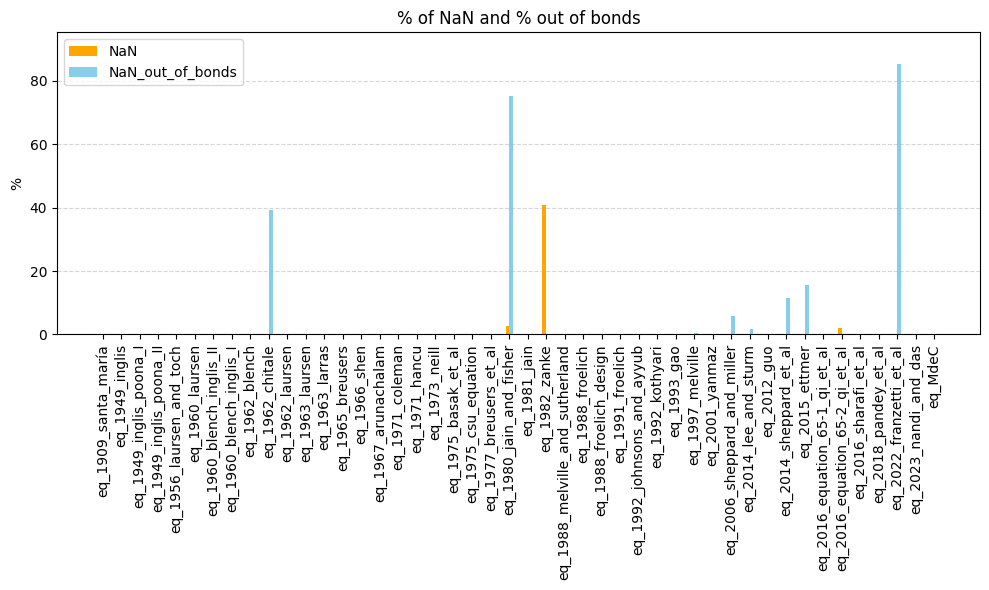

In [ ]:
equations = df_subcritic_cal['equation'].unique()
data = []

for eq in equations:
    df_eq = df_subcritic_cal[df_subcritic_cal['equation'] == eq]
    total = len(df_eq)

    count_nan = df_eq['cal'].isna().sum()
    count_out = (df_eq['cal'] == 'NaN_out_of_bonds').sum()

    pct_nan = (count_nan / total) * 100 if total > 0 else 0
    pct_out = (count_out / total) * 100 if total > 0 else 0

    data.append([eq, pct_nan, pct_out])

df_plot = pd.DataFrame(data, columns=['equation', 'pct_nan', 'pct_out'])

# gráfico de barras agrupadas
x = np.arange(len(df_plot))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_plot['pct_nan'], width, label='NaN', color='orange')
plt.bar(x + width/2, df_plot['pct_out'], width, label='NaN_out_of_bonds', color='skyblue')

# etiquetas
plt.xticks(x, df_plot['equation'], rotation=90)  # verticales
plt.ylabel('%')
plt.title('% of NaN and % out of bonds')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(df_plot['pct_nan'].max(), df_plot['pct_out'].max()) + 10)
plt.show()

#display(df_plot)

In [ ]:
# replace 'NaN_out_of_bonds' per NaN
df_subcritic_cal['cal'] = df_subcritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)
df_supercritic_cal['cal'] = df_supercritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)

# calculate dimensionless scour
df_subcritic_cal['cal_dimensionless'] = df_subcritic_cal['cal'] / df_subcritic_cal['b']
df_supercritic_cal['cal_dimensionless'] = df_supercritic_cal['cal'] / df_supercritic_cal['b']

/tmp/ipython-input-790910007.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subcritic_cal['cal'] = df_subcritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)
/tmp/ipython-input-790910007.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_supercritic_cal['cal'] = df_supercritic_cal['cal'].replace('NaN_out_of_bonds', np.nan)


*  df_subcritic_cal has in **each row** : **one observation** and **one calulation**; total row number is = observations * applied equations

In [ ]:
# Export
df_subcritic_cal.to_csv('data_processed/df_subcritic_cal.csv', index=False)
df_supercritic_cal.to_csv('data_processed/df_supercritic_cal.csv', index=False)

## Equations perfomance assestment

In [ ]:
# Read csv with results of equations
#df_subcritic_cal = pd.read_csv('data_processed/df_subcritic_cal.csv')
#df_supercritic_cal = pd.read_csv('data_processed/df_supercritic_cal.csv')

# Group by the 'equation' column
equations = df_subcritic_cal['equation'].unique()

##### Metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def analyze_metrics_for_df(df, equations, output_path):
    metrics_list = []

    for i, equation in enumerate(equations):
        equation_data = df[df['equation'] == equation]
        observed = equation_data['obs_dimensionless']
        calculated = equation_data['cal_dimensionless']

        parts = equation.split('_')
        formatted_title = f"{parts[1]} {' '.join(parts[2:]).title()}"

        mask = ~np.isnan(observed) & ~np.isnan(calculated)
        obs_filtered = observed[mask]
        cal_filtered = calculated[mask]

        if len(obs_filtered) == 0:
            continue

        r2 = r2_score(obs_filtered, cal_filtered)
        mae = mean_absolute_error(obs_filtered, cal_filtered)
        rmse = np.sqrt(mean_squared_error(obs_filtered, cal_filtered))
        mape = np.mean(np.abs((obs_filtered - cal_filtered) / obs_filtered)) * 100

        relative_error = (cal_filtered - obs_filtered) / obs_filtered
        error_over_10 = np.sum(relative_error > 0.10)
        error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
        error_under_10 = np.sum(relative_error < -0.10)
        total = len(relative_error)

        over_pct = 100 * error_over_10 / total
        within_pct = 100 * error_within_10 / total
        under_pct = 100 * error_under_10 / total

        metrics_list.append({
            "Equation": formatted_title,
            "R2": round(r2, 2),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2),
            "> +10%": round(over_pct, 1),
            "±10%": round(within_pct, 1),
            "< -10%": round(under_pct, 1)
        })

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.to_csv(output_path, index=False)

    print(f"Métricas guardadas en: {output_path}")
    print("\nDataFrame de métricas generado:")
    display(df_metrics)


In [ ]:
# Subcritic
analyze_metrics_for_df(
    df=df_subcritic_cal,
    equations=equations,
    output_path="results/metrics/metrics_subcritic_equations_V2.csv"
)

Métricas guardadas en: results/metrics/metrics_subcritic_equations_V2.csv

DataFrame de métricas generado:


,Equation,R2,MAE,RMSE,MAPE (%),> +10%,±10%,< -10%
0,1909 Santa María,-17.96,1.66,2.71,185.84,33.4,2.6,64.1
1,1949 Inglis,-76.49,4.37,5.48,487.04,99.0,0.9,0.1
2,1949 Inglis Poona I,-2.57,0.82,1.17,77.62,39.8,11.0,49.3
3,1949 Inglis Poona Ii,-117.56,4.34,6.77,290.82,60.3,1.3,38.4
4,1956 Laursen And Toch,-1.09,0.68,0.90,130.98,68.2,23.8,8.0
5,1960 Laursen,-4.14,1.08,1.41,180.81,81.0,13.3,5.7
6,1960 Blench Inglis Ii,-3.72,1.10,1.35,96.39,42.3,3.7,53.9
7,1960 Blench Inglis I,-3.83,1.20,1.37,125.67,28.8,2.5,68.8
8,1962 Blench,-0.28,0.59,0.70,72.64,29.1,5.1,65.8
9,1962 Chitale,-11.14,1.49,2.12,211.48,73.9,6.7,19.4


In [ ]:
# Supercritic
analyze_metrics_for_df(
    df=df_supercritic_cal,
    equations=equations,
    output_path="results/metrics/metrics_supercritic_equations_V2.csv"
)

Métricas guardadas en: results/metrics/metrics_supercritic_equations_V2.csv

DataFrame de métricas generado:


,Equation,R2,MAE,RMSE,MAPE (%),> +10%,±10%,< -10%
0,1909 Santa María,-16.31,1.53,2.25,93.35,37.4,7.7,54.9
1,1949 Inglis,-232.11,6.70,8.26,418.92,98.9,1.1,0.0
2,1949 Inglis Poona I,-25.86,2.21,2.80,144.76,97.8,1.1,1.1
3,1949 Inglis Poona Ii,-1003.27,15.57,17.15,1119.90,98.9,1.1,0.0
4,1956 Laursen And Toch,0.40,0.31,0.42,24.80,30.8,41.8,27.5
5,1960 Laursen,-0.56,0.50,0.68,33.72,56.0,22.0,22.0
6,1960 Blench Inglis Ii,-36.74,3.22,3.32,250.24,97.8,2.2,0.0
7,1960 Blench Inglis I,-8.49,1.57,1.67,97.97,0.0,1.1,98.9
8,1962 Blench,-1.35,0.72,0.83,41.02,1.1,6.6,92.3
9,1962 Laursen,0.05,0.40,0.53,26.15,29.7,26.4,44.0


##### Figures

In [ ]:
# --- Determine Global X-axis Limits ---
all_observed_values = df_subcritic_cal['obs_dimensionless'].dropna()
global_x_min = np.floor(all_observed_values.min() * 0.9) if not all_observed_values.empty else 0
global_x_max = np.ceil(all_observed_values.max() * 1.1) if not all_observed_values.empty else 10
if global_x_max - global_x_min < 1:
    global_x_max = global_x_min + 1
print(f"Global X-axis (Observed) Range: [{global_x_min:.2f}, {global_x_max:.2f}]")

Global X-axis (Observed) Range: [0.00, 4.00]


In [ ]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# --- Define the enhanced plot_results function ---
def plot_results(ax, observed, calculated, title, global_x_min, global_x_max):
    """
    Plots observed vs. calculated values with custom styling,
    error bands, percentage of points within/outside bands,
    and line labels.

    Parameters:
    - ax: The matplotlib axes object to plot on.
    - observed (pd.Series or np.array): The observed (true) values.
    - calculated (pd.Series or np.array): The calculated (predicted) values.
    - title (str): The title for the subplot.
    - global_x_min (float): The minimum limit for the X-axis (global across all plots).
    - global_x_max (float): The maximum limit for the X-axis (global across all plots).
    """
    # Scatter plot
    sns.scatterplot(x=observed, y=calculated, alpha=0.3, ax=ax, edgecolors='black', facecolors='none', s=50)

    # Calculate metrics for percentages
    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask]
    cal_filtered = calculated[mask]

    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\nNo valid data")
        ax.axis('off')
        return

    relative_error = (cal_filtered - obs_filtered) / obs_filtered
    error_over_10 = np.sum(relative_error > 0.10)
    error_within_10 = np.sum(np.abs(relative_error) <= 0.10)
    error_under_10 = np.sum(relative_error < -0.10)
    total = len(relative_error)

    # Handle division by zero for percentages if total is 0
    if total == 0:
        over_pct = 0
        within_pct = 0
        under_pct = 0
    else:
        over_pct = 100 * error_over_10 / total
        within_pct = 100 * error_within_10 / total
        under_pct = 100 * error_under_10 / total

    # --- Add 10% error lines and fill ---
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range * 1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range * 0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range * 0.90, line_plot_range * 1.10, color='gray', alpha=0.2)
    # ----------------------------------------

    ax.set_xlabel('Observed', fontsize=8)
    ax.set_ylabel('Calculated', fontsize=8)

    # Set X-axis limits using the global range
    ax.set_xlim(global_x_min, global_x_max)

    # --- Set Y-axis (starts from 0, min top 4, dynamic upper limit) ---
    current_y_max = cal_filtered.max() if len(cal_filtered) > 0 else 0.1
    current_y_max_padded = max(1.0, np.ceil(current_y_max * 1.1))
    if current_y_max_padded < 4:
        current_y_max_padded = 4
    ax.set_ylim(bottom=0, top=current_y_max_padded)
    # -----------------------------------------------------------------

    ax.xaxis.set_major_locator(MultipleLocator(1))
    y_tick_step = max(1, int(current_y_max_padded / 4))
    if y_tick_step == 0: y_tick_step = 0.5
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=14)

    # --- Add text labels for lines and band (no rotation, simplified text) ---
    # Position them slightly before the global_x_max for right alignment
    text_x_pos = global_x_max * 0.85

    # +10% Line label
    ax.text(text_x_pos, text_x_pos * 1.10, '+10%',
            horizontalalignment='right', verticalalignment='bottom',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # -10% Line label
    ax.text(text_x_pos, text_x_pos * 0.90, '-10%',
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=9, rotation=0,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # 10% Error Band label
    #band_text_x = (global_x_min + global_x_max) / 2
    #band_text_y = band_text_x # Centered on the 1:1 conceptual line for the band label
    #ax.text(band_text_x, band_text_y, '10% Error Band',
            #horizontalalignment='center', verticalalignment='center',
            #color='gray', fontsize=7, alpha=0.8,
            #bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))


    # --- Add percentage text based on band positions ---
    #mid_x_for_pct_text = 3 # Fixed x-position for these percentage labels
    #buffer_y = 0.02 * (current_y_max_padded - 0)

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text, f'{within_pct:.0f}%',
            #horizontalalignment='center', verticalalignment='center',
            #color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text * 1.10 + buffer_y, f'{over_pct:.0f}%',
           # horizontalalignment='center', verticalalignment='bottom',
           # color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    #ax.text(mid_x_for_pct_text, mid_x_for_pct_text * 0.90 - buffer_y, f'#{under_pct:.0f}%',
            #horizontalalignment='center', verticalalignment='top',
            #color='black', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_equations(df_to_plot, equations, output_prefix, global_x_min, global_x_max):
    """
    Plots multiple equation performance charts from a DataFrame, adjusting the
    number of rows in the last figure to avoid empty space.

    Args:
        df_to_plot (pd.DataFrame): The DataFrame containing the data to plot.
        equations (list): List of equation names.
        output_prefix (str): Prefix for the output file name (e.g., 'subcritic', 'supercritic').
        global_x_min (float): Minimum value for the x-axis.
        global_x_max (float): Maximum value for the y-axis.
    """
    # Define plot configuration
    plots_per_row = 4
    rows_per_figure_base = 6
    plots_per_figure = plots_per_row * rows_per_figure_base

    # Calculate total figures needed
    num_equations = len(equations)
    num_figures = math.ceil(num_equations / plots_per_figure)

    # Initialize figure counter
    figure_num = 1

    # Iterate over equations and create figures
    for fig_idx in range(num_figures):
        start_eq_idx = fig_idx * plots_per_figure
        end_eq_idx = min((fig_idx + 1) * plots_per_figure, num_equations)
        current_equations = equations[start_eq_idx:end_eq_idx]

        # Calculate the number of rows for the current figure
        if fig_idx == num_figures - 1:
            # For the last figure, calculate required rows dynamically
            num_plots_last_figure = len(current_equations)
            rows_per_figure = math.ceil(num_plots_last_figure / plots_per_row)
            if rows_per_figure == 0:  # Ensure at least one row if there are plots
                rows_per_figure = 1
        else:
            # Use the base number of rows for all other figures
            rows_per_figure = rows_per_figure_base

        # Create the figure and axes
        fig, axes = plt.subplots(rows_per_figure, plots_per_row, figsize=(14, rows_per_figure * 3))
        axes = axes.flatten()

        for i, equation in enumerate(current_equations):
            equation_data = df_to_plot[df_to_plot['equation'] == equation]
            observed = equation_data['obs_dimensionless']
            calculated = equation_data['cal_dimensionless']

            # Plot title formatting
            parts = equation.split('_')
            year = parts[1]
            author_raw = ' '.join(parts[2:]).replace('_', ' ').title()
            author = author_raw.replace('And', 'and').replace('Et Al', 'et al.').replace('Ii', 'II').replace('Csu', 'CSU')
            formatted_title = f"{author} ({year})"

            # This is a placeholder for your actual plotting function
            # You must define `plot_results` separately
            plot_results(axes[i], observed, calculated, formatted_title, global_x_min, global_x_max)

        # Hide any unused subplots, especially in the last figure
        for j in range(len(current_equations), len(axes)):
            axes[j].axis('off')

        plt.tight_layout()

        # Save the figure
        output_filename_jpeg = f"results/figures/{output_prefix}_{figure_num}.jpeg"
        plt.savefig(output_filename_jpeg, format='jpeg', dpi=1000, bbox_inches='tight')
        plt.show()
        plt.close(fig)

        figure_num += 1

In [ ]:
def plot_results_V2(
    ax, observed, calculated, title, global_x_min, global_x_max,
    title_fs=12, label_fs=10, tick_fs=9, line_label_fs=9
):
    sns.scatterplot(x=observed, y=calculated, alpha=0.3, ax=ax,
                    edgecolors='black', facecolors='none', s=50)

    mask = ~np.isnan(observed) & ~np.isnan(calculated)
    obs_filtered = observed[mask];  cal_filtered = calculated[mask]
    if len(obs_filtered) == 0:
        ax.set_title(f"{title}\nNo valid data", fontsize=title_fs); ax.axis('off'); return

    relative_error = (cal_filtered - obs_filtered) / obs_filtered
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range*1.10, color='black', linestyle=':')
    ax.plot(line_plot_range, line_plot_range*0.90, color='black', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range*0.90, line_plot_range*1.10,
                    color='gray', alpha=0.2)

    ax.set_xlabel('Observado', fontsize=label_fs)
    ax.set_ylabel('Calculado', fontsize=label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)

    ax.set_xlim(global_x_min, global_x_max)
    current_y_max = cal_filtered.max() if len(cal_filtered)>0 else 0.1
    current_y_max_padded = max(4, np.ceil(current_y_max*1.1))
    ax.set_ylim(bottom=0, top=current_y_max_padded)

    ax.xaxis.set_major_locator(MultipleLocator(1))
    y_tick_step = max(1, int(current_y_max_padded/4))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))

    ax.set_title(title, fontsize=title_fs)

    text_x_pos = global_x_max * 0.85
    ax.text(text_x_pos, text_x_pos*1.10, '+10%',
            ha='right', va='bottom', fontsize=line_label_fs,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    ax.text(text_x_pos, text_x_pos*0.90, '-10%',
            ha='right', va='top', fontsize=line_label_fs,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))


In [ ]:
import math
import matplotlib.pyplot as plt

def plot_equations_V2(
    df_to_plot, equations, output_prefix, global_x_min, global_x_max,
    figure_title=None, title_map=None, figure_title_y=0.97,
    # tamaños
    figure_title_size=14, per_axes_title_size=14,
    axis_label_size=12, tick_size=11, line_label_size=11
):
    plots_per_row = 2
    rows_per_figure_base = 6
    plots_per_figure = plots_per_row * rows_per_figure_base

    num_equations = len(equations)
    num_figures = math.ceil(num_equations / plots_per_figure)
    figure_num = 1

    for fig_idx in range(num_figures):
        start_eq_idx = fig_idx * plots_per_figure
        end_eq_idx = min((fig_idx + 1) * plots_per_figure, num_equations)
        current_equations = equations[start_eq_idx:end_eq_idx]

        # filas dinámicas solo en la última página
        if fig_idx < num_figures - 1:
            rows_per_figure = rows_per_figure_base
        else:
            rows_per_figure = max(1, math.ceil(len(current_equations) / plots_per_row))

        # --- figura y ejes (sin constrained_layout) ---
        fig, axes = plt.subplots(
            rows_per_figure, plots_per_row,
            figsize=(10, rows_per_figure * 3.2)
        )
        axes = axes.flatten()

        # --- título general tipo sgtitle ---
        if figure_title:
            fig.suptitle(figure_title, fontsize=figure_title_size, y=figure_title_y)
            # deja margen arriba para el título
            plt.tight_layout(rect=(0.02, 0.02, 0.98, 0.92))
        else:
            plt.tight_layout()

        # --- dibujar cada ecuación ---
        for i, equation in enumerate(current_equations):
            eqdf = df_to_plot[df_to_plot['equation'] == equation]
            observed = eqdf['obs_dimensionless']
            calculated = eqdf['cal_dimensionless']

            # título individual (permite overrides vía title_map)
            if title_map and equation in title_map:
                formatted_title = title_map[equation]
            else:
                parts = equation.split('_')
                year = parts[1] if len(parts) > 1 else ''
                author_raw = ' '.join(parts[2:]).replace('_', ' ').title()
                author = (author_raw.replace('And', 'and')
                                   .replace('Et Al', 'et al.')
                                   .replace('Ii', 'II')
                                   .replace('Csu', 'CSU'))
                formatted_title = (
                    'HEC-18' if ('hec' in equation.lower() and year in ('18', '2018'))
                    else (f"{author} ({year})" if year else author)
                )

            plot_results_V2(
                axes[i], observed, calculated, formatted_title,
                global_x_min, global_x_max,
                title_fs=per_axes_title_size,
                label_fs=axis_label_size,
                tick_fs=tick_size,
                line_label_fs=line_label_size
            )

        # ocultar ejes sobrantes
        for j in range(len(current_equations), len(axes)):
            axes[j].axis('off')

        # --- limpiar labels repetidos y mejorar espacios ---
        for i, ax in enumerate(axes[:len(current_equations)]):
          row = i // plots_per_row
          col = i %  plots_per_row
        if row < rows_per_figure - 1:   # no es última fila
          ax.set_xlabel('')
        if col > 0:                     # no es 1ª columna
          ax.set_ylabel('')

# más aire entre subplots
        fig.subplots_adjust(hspace=0.35, wspace=0.28)  # ajusta a tu gusto


        # guardar y cerrar
        out = f"results/figures/{output_prefix}_{figure_num}.jpeg"
        fig.savefig(out, format='jpeg', dpi=1000, bbox_inches='tight')
        plt.show()
        plt.close(fig)

        figure_num += 1



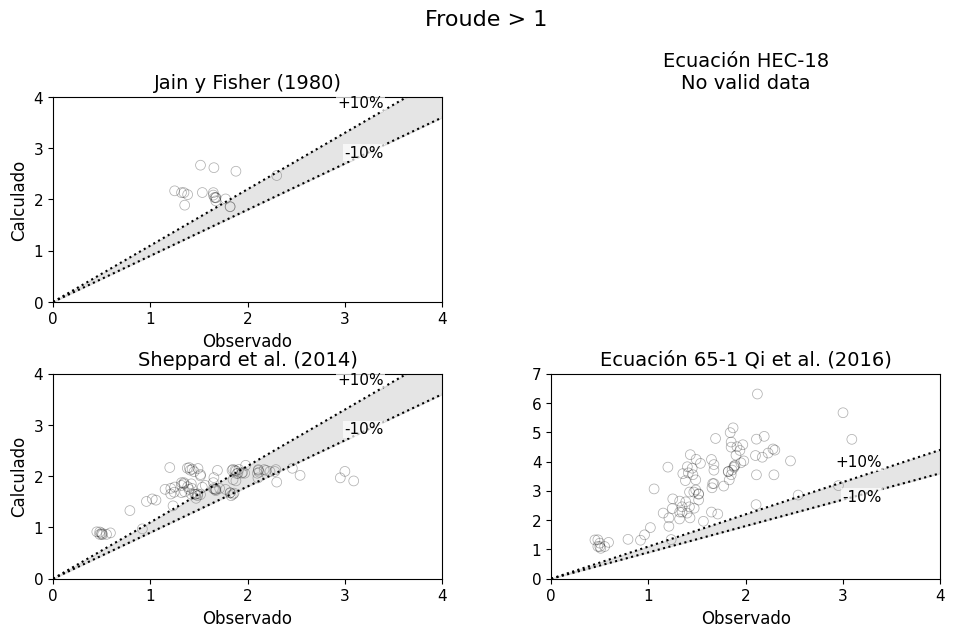

In [ ]:
plot_equations_V2(
    df_to_plot=df_supercritic_cal,
    equations=[
        'eq_1980_jain_and_fisher',
        'eq_18_HEC',
        'eq_2014_sheppard_et_al',
        'eq_2016_equation_65-1_qi_et_al'
    ],
    output_prefix="Figure_23",
    global_x_min=global_x_min,
    global_x_max=global_x_max,
    figure_title="Froude > 1",
    title_map={'eq_1980_jain_and_fisher': 'Jain y Fisher (1980)','eq_18_HEC': 'Ecuación HEC-18','eq_2016_equation_65-1_qi_et_al': 'Ecuación 65-1 Qi et al. (2016)' },   # renombre puntual
    # (opcionales) tamaños
    figure_title_size=16,
    per_axes_title_size=14,
    axis_label_size=12,
    tick_size=11,
    line_label_size=11
)


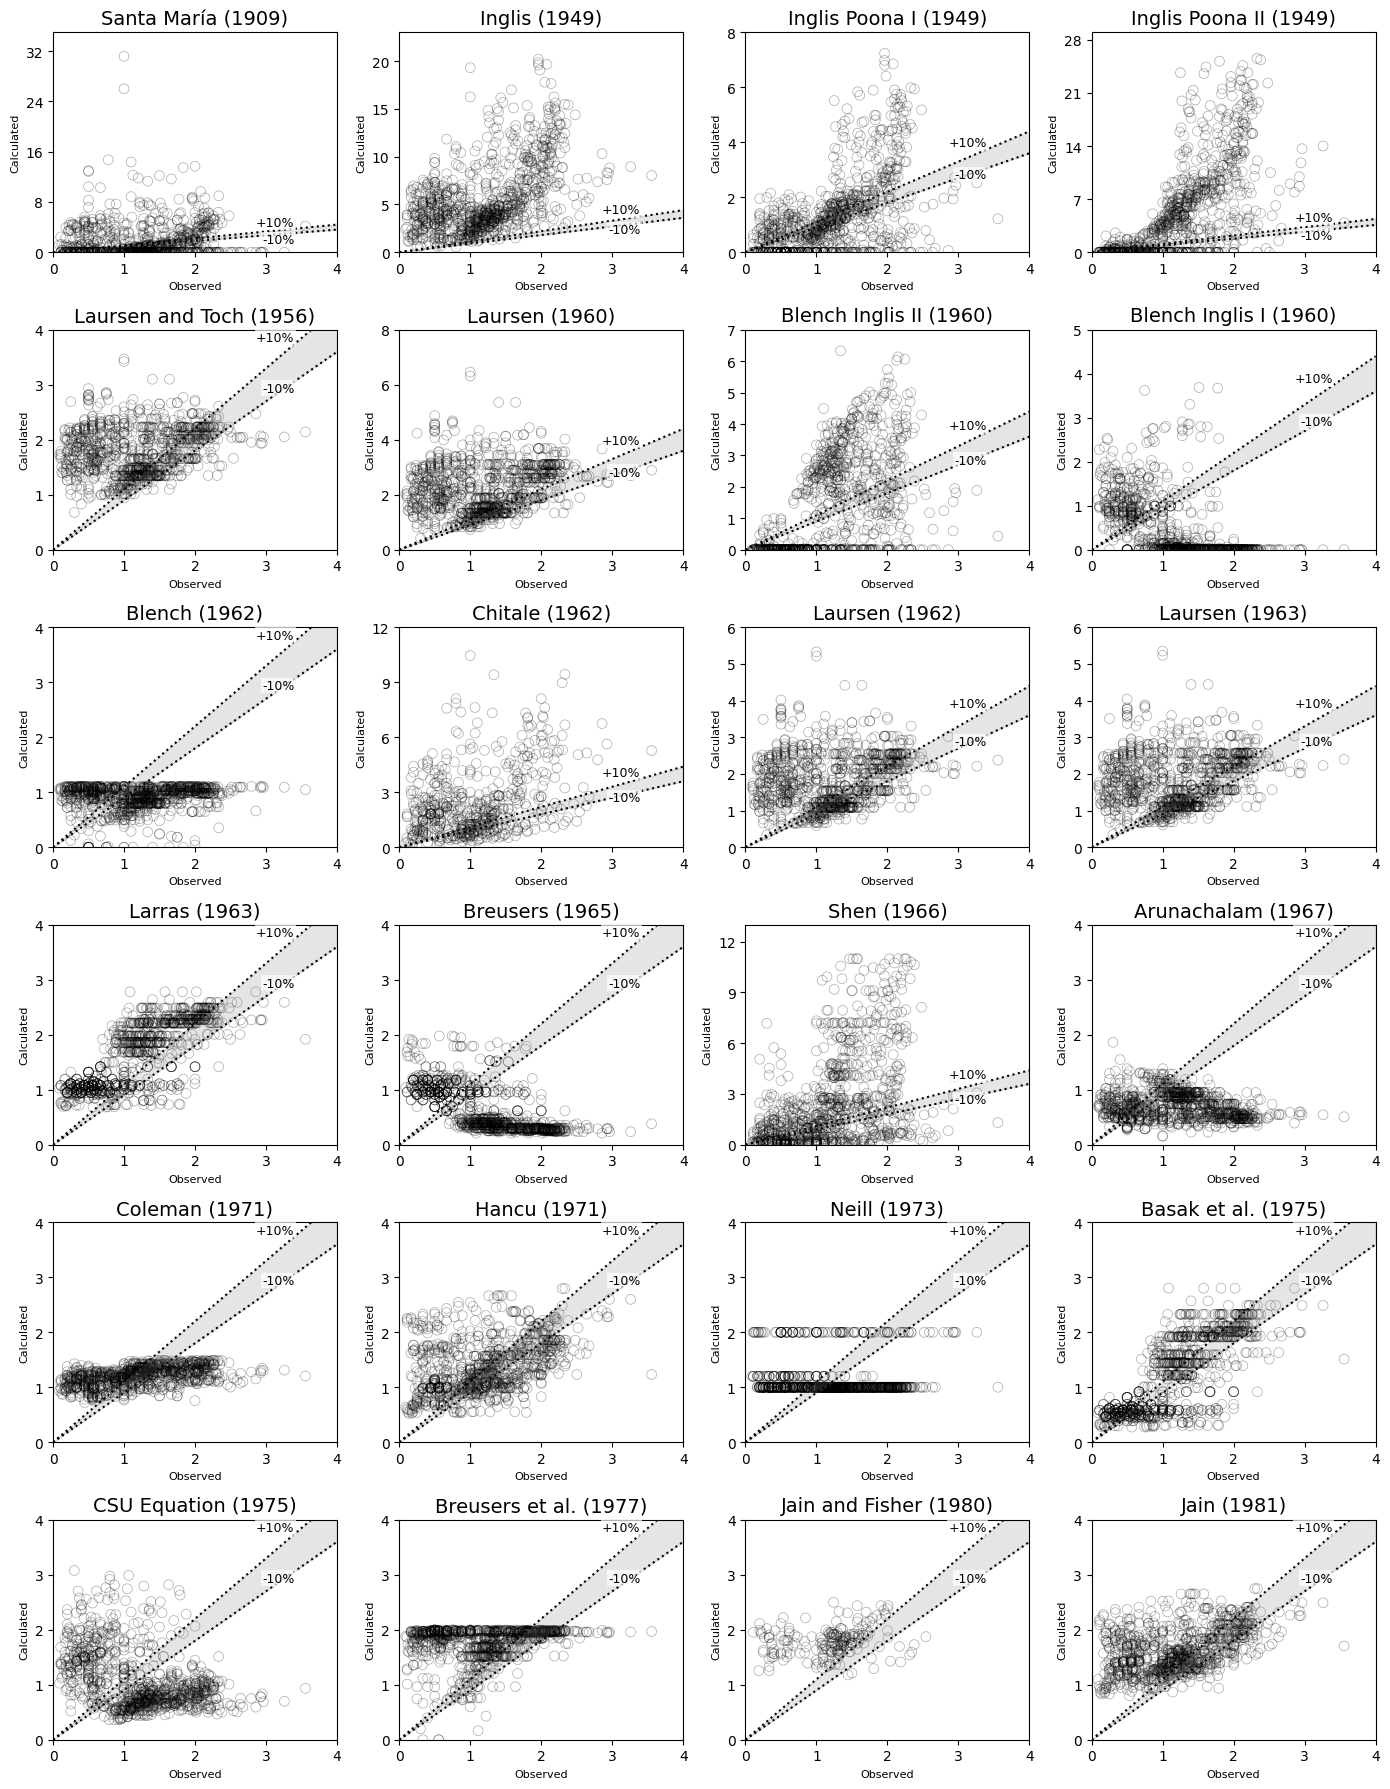

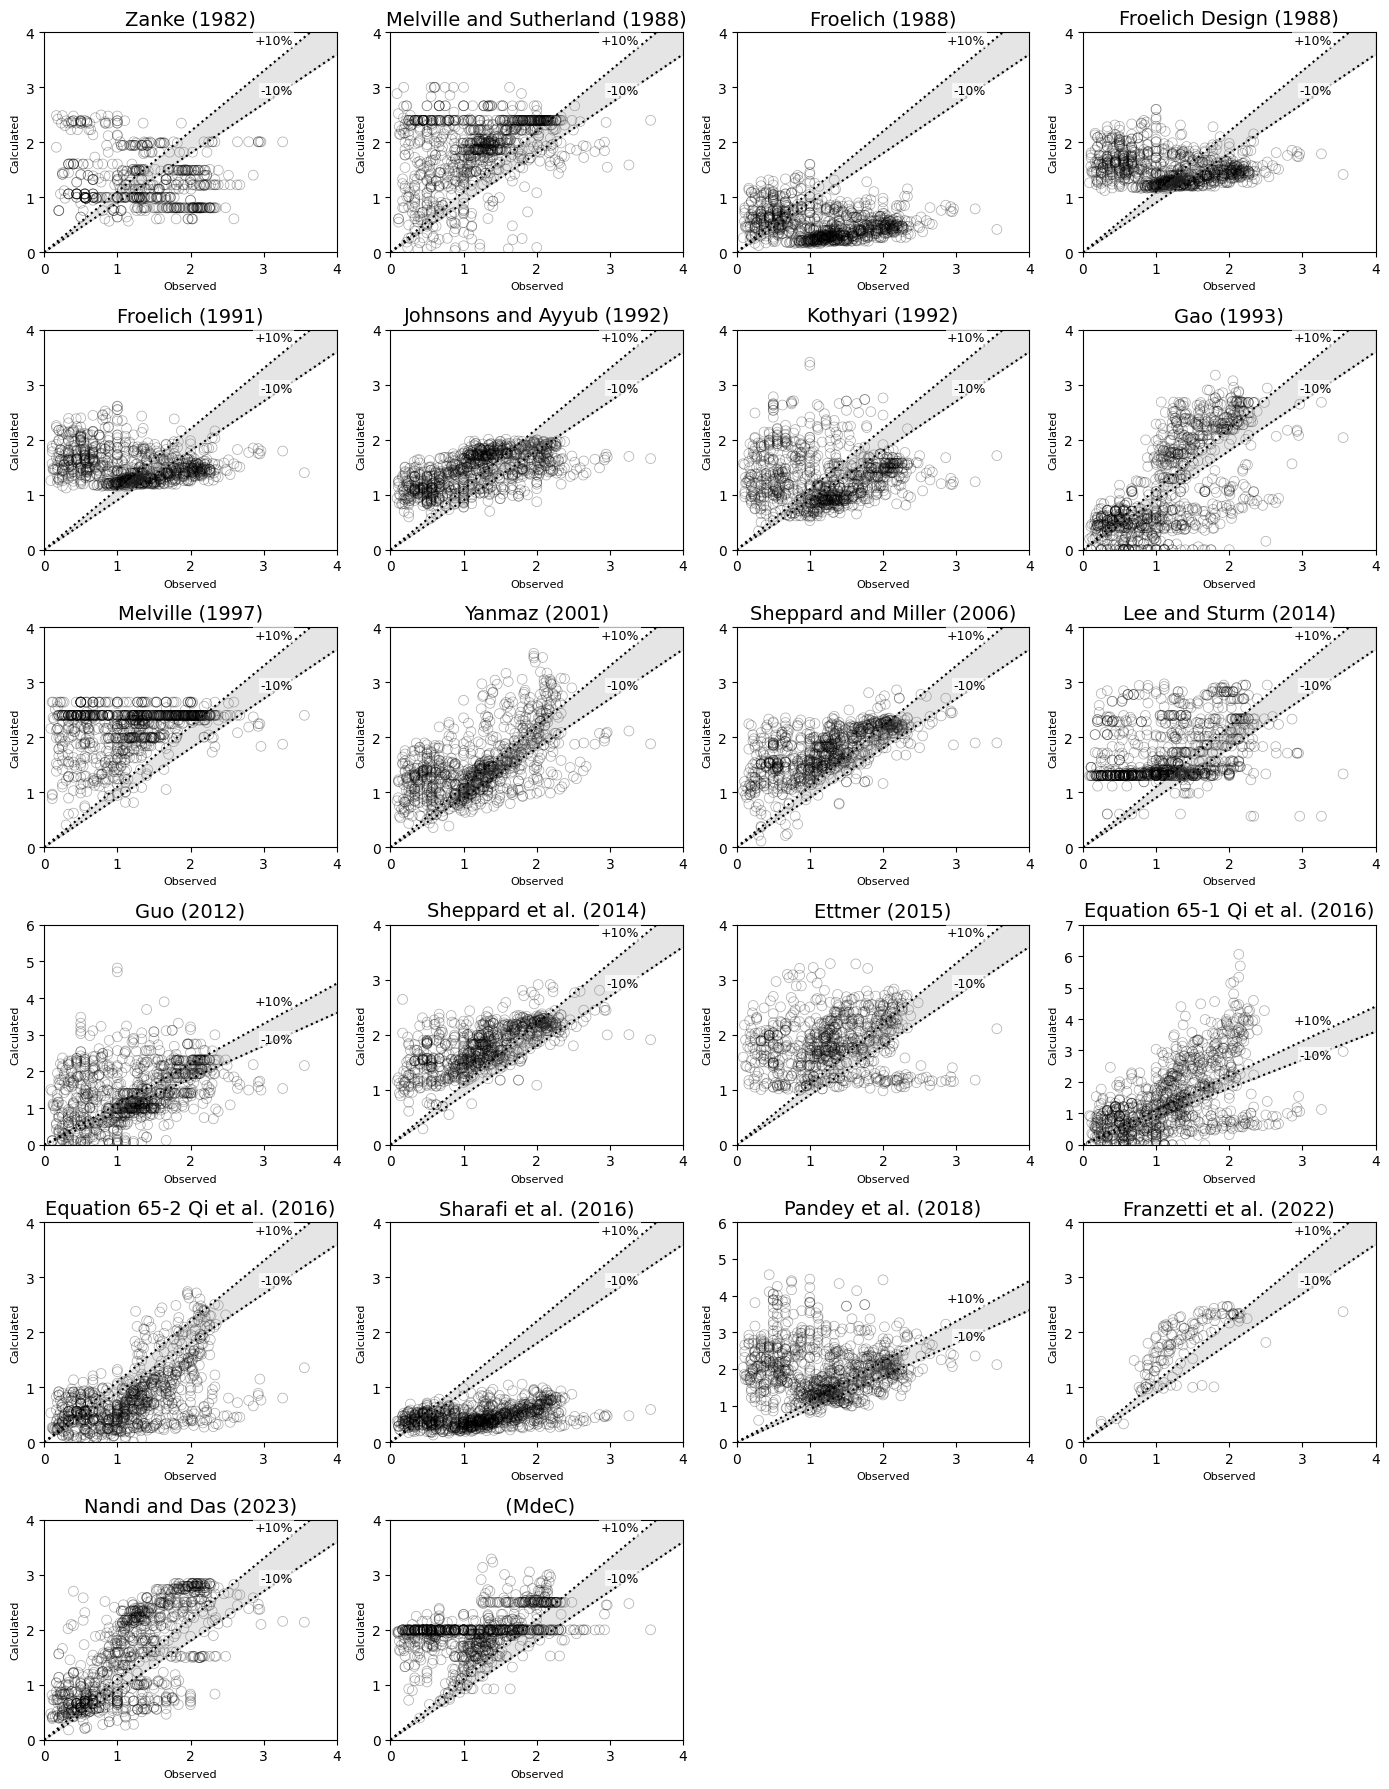

In [ ]:
plot_equations(
    df_to_plot=df_subcritic_cal,
    equations=equations,
    output_prefix="Figure_2",
    global_x_min=global_x_min,
    global_x_max=global_x_max
)

In [ ]:
def plot_all_equations_on_one_plot(df_to_plot, equations, output_prefix, global_x_min, global_x_max):
    """
    Plots the performance of all equations on a single scatter plot.

    Args:
        df_to_plot (pd.DataFrame): The DataFrame containing the data to plot.
        equations (list): List of equation names.
        output_prefix (str): Prefix for the output file name (e.g., 'subcritic', 'supercritic').
        global_x_min (float): Minimum value for the x-axis.
        global_x_max (float): Maximum value for the y-axis.
    """
    # Create a single figure and a single axis
    fig, ax = plt.subplots(figsize=(4, 3))
    point_color = 'black'
    marker_size = 3

    for equation in equations:
        equation_data = df_to_plot[df_to_plot['equation'] == equation]
        observed = equation_data['obs_dimensionless']
        calculated = equation_data['cal_dimensionless']

        ax.scatter(observed, calculated,
                   s=marker_size,
                   c=point_color,
                   alpha=0.6)

    # Add the 45-degree perfect fit line
    ax.plot([global_x_min, global_x_max], [global_x_min, global_x_max],
            color='gray', linestyle='--', linewidth=1.5, label='Perfect Fit')

    # Set plot title and labels
    ax.set_xlabel('Observed')
    ax.set_ylabel('Calculated')
    ax.set_xlim(global_x_min, global_x_max)
    ax.set_ylim(global_x_min, global_x_max)
    ax.grid(False) # Turn off the grid

    # Adjust layout and add legend
    ax.legend(loc='lower right')
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # Save the single figure
    output_filename_jpeg = f"results/figures/{output_prefix}_all_equations_single_plot.jpeg"
    plt.savefig(output_filename_jpeg, format='jpeg', dpi=1000, bbox_inches='tight')
    plt.show()
    plt.close(fig)


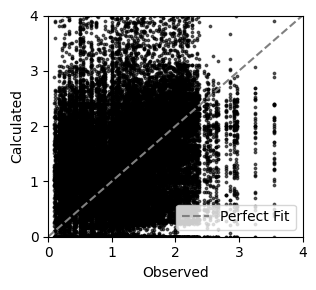

In [ ]:
plot_all_equations_on_one_plot(
    df_to_plot=df_subcritic_cal,
    equations=equations,
    output_prefix="Figure_2",
    global_x_min=global_x_min,
    global_x_max=global_x_max
)

# Machine Learning Models

Predict the scour, training two models with the same dataset but diferents variables: (1) the dataset with hydraulic variables (2) the dataset with the predicted values of scour made by the equations provided

#### Dataset with subcritic flow

In [ ]:
# Read csv with results of equations
df_subcritic_cal = pd.read_csv('data_processed/df_subcritic_cal.csv')

In [ ]:
# Convert the calculated values by equations in diferents columnns
df_wide = df_subcritic_cal.pivot(index='id', columns='equation', values='cal_dimensionless').add_prefix('cal_').reset_index()

# merge with df
df_subcritic_cal = df.merge(df_wide, on='id')

*   X1: Dataset 1 with columns containing hydraulic variables for calculating
*   X2: Dataset 2 with columns containing calculations of scour

In [ ]:
# Dataset 1: hydraulic variables as predictors
X1_subcritic = df_subcritic_cal[['b', 'h', 'v', 'd50','h/vcr','h/b','b/d50','b/h']]

# Dataset 2: outputs from equations as predictors
X2_subcritic = df_subcritic_cal.filter(like='cal')

# Define the target variable
y = df_subcritic_cal['obs_dimensionless']

# display both datasets
print('Dataset 1 (X1) - Hydraulic variables as predictors')
display(X1_subcritic)

print('\nDataset 2 (X2) - Outputs from equations as predictors')
display(X2_subcritic)

#### Dataset with supercritic flow

In [ ]:
# Read csv with results of equations
df_supercritic_cal = pd.read_csv('data_processed/df_supercritic_cal.csv')

In [ ]:
# convert the calculated values by equations in diferents columnns
df_wide = df_supercritic_cal.pivot(index='id', columns='equation', values='cal_dimensionless').add_prefix('cal_').reset_index()

# merge with df
df_supercritic_cal = df.merge(df_wide, on='id')

In [ ]:
# Define test sets for supercritical flows (Froude > 1)
X1_supercritic_test = df_supercritic_cal[['b', 'h', 'v', 'd50','h/vcr','h/b','b/d50','b/h']]
X2_supercritic_test = df_supercritic_cal.filter(like='cal')
y_supercritic_test = df_supercritic_cal['obs_dimensionless']

### Train and Test

*   Train with subcritic data
*   Test with subcritic data
*   Test with supercritic data



In [ ]:
results_test_subcritic = []
results_supercritic_test = []
seed = 42
np.random.seed(seed)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


class RegressorSwitcher(BaseEstimator):
    def __init__(self, estimator=RandomForestRegressor()):
        self.estimator = estimator
    def fit(self, X, y=None, **kwargs):
        self.estimator.fit(X, y)
        return self
    def predict(self, X):
        return self.estimator.predict(X)
    def score(self, X, y):
        return self.estimator.score(X, y)

def evaluate_model(model, X_test, y_test, dataset_name='X'):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    print(f'\n[RESULTADOS para {dataset_name}]')
    print(f'R2: {r2:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}')
    return {
        'dataset': dataset_name,
        'y_pred': y_pred,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }


In [ ]:
from skopt.space import Real, Integer, Categorical
from skopt import BayesSearchCV


def train_model(X_train, y_train, model_type='rf', seed=seed):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', RegressorSwitcher())
    ])

    if model_type == 'rf':
        # Define el espacio de búsqueda para Bayesiana
        search_spaces = {
            'reg__estimator': [RandomForestRegressor(criterion='squared_error', random_state=seed)],
            'reg__estimator__n_estimators': Integer(10, 700),
            'reg__estimator__max_depth': Integer(2, 16),
            'reg__estimator__min_samples_split': Integer(5, 20),
            'reg__estimator__min_samples_leaf': Integer(5, 20),
            'reg__estimator__max_features': Categorical(['sqrt', 'log2']),
        }

    elif model_type == 'xgb':
        # Define el espacio de búsqueda para Bayesiana
        search_spaces = {
            'reg__estimator': [XGBRegressor(objective='reg:squarederror', random_state=seed)],
            'reg__estimator__n_estimators': Integer(10, 750),
            'reg__estimator__max_depth': Integer(2, 12),
            'reg__estimator__learning_rate': Real(0.01, 0.1, 'log-uniform'),
            'reg__estimator__subsample': Real(0.5, 0.7),
            'reg__estimator__colsample_bytree': Real(0.5, 0.7),
            'reg__estimator__gamma': Real(0.3, 1),
            'reg__estimator__reg_alpha': Real(0.01, 2, 'log-uniform'),
            'reg__estimator__reg_lambda': Real(0.01, 2, 'log-uniform'),
            'reg__estimator__min_child_weight': Integer(5, 10)
        }

    cv = KFold(n_splits=10, shuffle=True, random_state=seed)

    # Reemplaza RandomizedSearchCV por BayesSearchCV
    bayes_search = BayesSearchCV(
        pipeline,
        search_spaces,
        n_iter=50,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=seed
    )

    bayes_search.fit(X_train, y_train)

    print(f'Mejores parámetros para {model_type}:', bayes_search.best_params_)
    return bayes_search

In [ ]:
best_avg_r2 = -1  # Inicializa con un valor muy bajo
best_run_number = -1
best_run_results = {}  # Diccionario para guardar solo los mejores resultados
best_run_models = {}

for run in range(4):
    print(f'\n>>> RUN {run+1} <<<')
    seed = seed + run

    # Split data into training and testing sets using indices
    train_idx, test_idx = train_test_split(df_subcritic_cal.index, test_size=0.25, random_state=seed)

    # Apply the same split to both datasets
    X1_subcritic_train, X1_subcritic_test = X1_subcritic.loc[train_idx], X1_subcritic.loc[test_idx]
    X2_subcritic_train, X2_subcritic_test = X2_subcritic.loc[train_idx], X2_subcritic.loc[test_idx]
    y_subcritic_train, y_subcritic_test = y.loc[train_idx], y.loc[test_idx]

    # Convert to numpy arrays
    X1_subcritic_train_np = X1_subcritic_train.to_numpy()
    X1_subcritic_test_np = X1_subcritic_test.to_numpy()
    X2_subcritic_train_np = X2_subcritic_train.to_numpy()
    X2_subcritic_test_np = X2_subcritic_test.to_numpy()
    y_subcritic_train_np = y_subcritic_train.to_numpy()
    y_subcritic_test_np = y_subcritic_test.to_numpy()

    # Ensure supercritic test data is in numpy format
    X1_supercritic_test_np = X1_supercritic_test.to_numpy()
    X2_supercritic_test_np = X2_supercritic_test.to_numpy()
    y_supercritic_test_np = y_supercritic_test.to_numpy()

    # --- Random Forest - X1 ---
    fitted_search_rf_X1 = train_model(X1_subcritic_train_np, y_subcritic_train_np, model_type='rf', seed=seed)
    model_rf_X1 = fitted_search_rf_X1.best_estimator_
    results_rf_X1_train = evaluate_model(model_rf_X1, X1_subcritic_train_np, y_subcritic_train_np, dataset_name=f'RF_X1_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_rf_X1_train)
    results_rf_X1_test = evaluate_model(model_rf_X1, X1_subcritic_test_np, y_subcritic_test_np, dataset_name=f'RF_X1_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_rf_X1_test)
    results_rf_X1_supercritic_test = evaluate_model(model_rf_X1, X1_supercritic_test_np, y_supercritic_test_np, dataset_name=f'RF_X1_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_rf_X1_supercritic_test)

    # --- XGB - X1 ---
    fitted_search_xgb_X1 = train_model(X1_subcritic_train_np, y_subcritic_train_np, model_type='xgb', seed=seed)
    model_xgb_X1 = fitted_search_xgb_X1.best_estimator_
    results_xgb_X1_train = evaluate_model(model_xgb_X1, X1_subcritic_train_np, y_subcritic_train_np, dataset_name=f'XGB_X1_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_xgb_X1_train)
    results_xgb_X1_test = evaluate_model(model_xgb_X1, X1_subcritic_test_np, y_subcritic_test_np, dataset_name=f'XGB_X1_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_xgb_X1_test)
    results_xgb_X1_supercritic_test = evaluate_model(model_xgb_X1, X1_supercritic_test_np, y_supercritic_test_np, dataset_name=f'XGB_X1_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_xgb_X1_supercritic_test)

    # --- Random Forest - X2 ---
    fitted_search_rf_X2 = train_model(X2_subcritic_train_np, y_subcritic_train_np, model_type='rf', seed=seed)
    model_rf_X2 = fitted_search_rf_X2.best_estimator_
    results_rf_X2_train = evaluate_model(model_rf_X2, X2_subcritic_train_np, y_subcritic_train_np, dataset_name=f'RF_X2_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_rf_X2_train)
    results_rf_X2_test = evaluate_model(model_rf_X2, X2_subcritic_test_np, y_subcritic_test_np, dataset_name=f'RF_X2_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_rf_X2_test)
    results_rf_X2_supercritic_test = evaluate_model(model_rf_X2, X2_supercritic_test_np, y_supercritic_test_np, dataset_name=f'RF_X2_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_rf_X2_supercritic_test)

    # --- XGB - X2 ---
    fitted_search_xgb_X2 = train_model(X2_subcritic_train_np, y_subcritic_train_np, model_type='xgb', seed=seed)
    model_xgb_X2 = fitted_search_xgb_X2.best_estimator_
    results_xgb_X2_train = evaluate_model(model_xgb_X2, X2_subcritic_train_np, y_subcritic_train_np, dataset_name=f'XGB_X2_subcritic_train_run_{run+1}')
    results_test_subcritic.append(results_xgb_X2_train)
    results_xgb_X2_test = evaluate_model(model_xgb_X2, X2_subcritic_test_np, y_subcritic_test_np, dataset_name=f'XGB_X2_subcritic_test_run_{run+1}')
    results_test_subcritic.append(results_xgb_X2_test)
    results_xgb_X2_supercritic_test = evaluate_model(model_xgb_X2, X2_supercritic_test_np, y_supercritic_test_np, dataset_name=f'XGB_X2_supercritic_test_run_{run+1}')
    results_supercritic_test.append(results_xgb_X2_supercritic_test)


    # R2
    r2_values = [
        results_rf_X1_test['r2'],
        results_xgb_X1_test['r2'],
        results_rf_X2_test['r2'],
        results_xgb_X2_test['r2']
    ]
    avg_r2_current_run = sum(r2_values) / len(r2_values)
    print(f"Promedio de R2 para la ejecución {run+1}: {avg_r2_current_run:.4f}")

    # Compare and save ---
    if avg_r2_current_run > best_avg_r2:
        best_avg_r2 = avg_r2_current_run

        # Guarda los datos y los resultados de la mejor ejecución
        best_run_data = {
            'y_train': y_subcritic_train_np,
            'results_rf_X1_train': results_rf_X1_train,
            'results_xgb_X1_train': results_xgb_X1_train,
            'results_rf_X2_train': results_rf_X2_train,
            'results_xgb_X2_train': results_xgb_X2_train,
            'run_number': run + 1
        }

##### Metrics

In [ ]:
df_results = pd.DataFrame(results_test_subcritic)
display(df_results[['dataset', 'r2', 'rmse', 'mae', 'mape']])
df_results.to_csv("results/metrics/metrics_subcritic_repetition.csv", index=False)

In [ ]:
df_results_supercritic = pd.DataFrame(results_supercritic_test)
display(df_results_supercritic[['dataset', 'r2', 'rmse', 'mae', 'mape']])
df_results_supercritic.to_csv("results/metrics/metrics_train_supercritic_repetition.csv", index=False)

In [ ]:
# Create DataFrame from results.
df_results = pd.DataFrame(results_test_subcritic)

# Extract model name.
df_results['base_model'] = df_results['dataset'].str.replace(r'_train_run_\d+', '', regex=True)
df_results['base_model'] = df_results['base_model'].str.replace(r'_test_run_\d+', '', regex=True)

# Identify dataset type ('train' or 'test').
df_results['dataset_type'] = np.where(df_results['dataset'].str.contains('train'), 'train', 'test')

# --- Function to create summary tables ---
def generate_separated_summary(df_full_results, type_to_filter):
    # Filter data by 'train' or 'test'.
    df_subset = df_full_results[df_full_results['dataset_type'] == type_to_filter].copy()

    # Calculate mean and standard deviation for each metric.
    summary_stats = df_subset.groupby('base_model').agg(
        r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
        rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
        mape_mean=('mape', 'mean'), mape_std=('mape', 'std')
    )

    # Format output as "mean ± std".
    formatted_table = pd.DataFrame(index=summary_stats.index)
    metrics = ['r2', 'rmse', 'mae', 'mape']
    display_names = {'r2': 'R²', 'rmse': 'RMSE', 'mae': 'MAE', 'mape': 'MAPE (%)'}

    for metric in metrics:
        mean_val = summary_stats[f'{metric}_mean'].round(3).astype(str)
        std_val = summary_stats[f'{metric}_std'].round(3).astype(str)
        formatted_table[display_names[metric]] = mean_val + " ± " + std_val

    # Print and save the results.
    title = f"{type_to_filter.upper()} Results: Mean ± Std for Each Base Model"
    filename = f"results/metrics/metrics_{type_to_filter}.csv"

    print(f"\n--- {title} ---")
    display(formatted_table)
    formatted_table.to_csv(filename)
    print(f"Summary saved to '{filename}'")

# --- Run the function for both train and test data ---
generate_separated_summary(df_results, 'train')
generate_separated_summary(df_results, 'test')

In [ ]:
def generate_separated_summary(df_full_results, type_to_filter):
    # Filter data by 'train' or 'test'.
    df_subset = df_full_results[df_full_results['dataset_type'] == type_to_filter].copy()

    # Calculate mean and standard deviation for each metric.
    summary_stats = df_subset.groupby('base_model').agg(
        r2_mean=('r2', 'mean'), r2_std=('r2', 'std'),
        rmse_mean=('rmse', 'mean'), rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'), mae_std=('mae', 'std'),
        mape_mean=('mape', 'mean'), mape_std=('mape', 'std')
    )

    # Format output as "mean ± std".
    formatted_table = pd.DataFrame(index=summary_stats.index)
    metrics = ['r2', 'rmse', 'mae', 'mape']
    display_names = {'r2': 'R²', 'rmse': 'RMSE', 'mae': 'MAE', 'mape': 'MAPE (%)'}

    for metric in metrics:
        mean_val = summary_stats[f'{metric}_mean'].round(3).astype(str)
        std_val = summary_stats[f'{metric}_std'].round(3).astype(str)
        formatted_table[display_names[metric]] = mean_val + " ± " + std_val

    # Print and save the results.
    title = f"{type_to_filter.upper()} Results: Mean ± Std for Each Base Model"
    filename = f"results/metrics/metrics_{type_to_filter}.csv"

    print(f"\n--- {title} ---")
    display(formatted_table) # <-- Replaced display() with print()
    formatted_table.to_csv(filename)

In [ ]:
# Create DataFrame from results.
df_results_supercritic = pd.DataFrame(results_supercritic_test)

# Extract model name.
df_results_supercritic['base_model'] = df_results_supercritic['dataset'].str.replace(r'_train_run_\d+', '', regex=True)
df_results_supercritic['base_model'] = df_results_supercritic['base_model'].str.replace(r'_test_run_\d+', '', regex=True)

# AGREGAR ESTA LÍNEA para eliminar el sufijo _run_# de los nombres de los modelos.
df_results_supercritic['base_model'] = df_results_supercritic['base_model'].str.replace(r'_run_\d+', '', regex=True)

# Identify dataset type ('train' or 'test').
df_results_supercritic['dataset_type'] = np.where(df_results_supercritic['dataset'].str.contains('train'), 'train', 'test')

# Run the function with the corrected DataFrame.
generate_separated_summary(df_results_supercritic, 'test')

##### Figures

###### Models 1

In [ ]:
# Plot only X1 results.
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_rf_X1_train['y_pred'],
    'RF1 - Train',  # Título para el conjunto de entrenamiento
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_xgb_X1_train['y_pred'],
    'XGB1 - Train',  # Título para el conjunto de entrenamiento
    global_x_min,
    global_x_max
)

# Save figure.
plt.savefig('results/figures/Figure_3.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show();

In [ ]:
# Plot only X1 results.
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_subcritic_test_np,
    # Calculated
    results_rf_X1_test['y_pred'],
    'RF1 - Test',
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    # Observed
    y_subcritic_test_np,
    # Calculated
    results_xgb_X1_test['y_pred'],
    'XGB1 - Test',
    global_x_min,
    global_x_max
)

# Save figure.
plt.savefig('results/figures/Figure_4.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_supercritic_test,
    # Calculated
    results_rf_X1_supercritic_test['y_pred'],

    'RF1 - Test Supercritic',
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    # Observed
    y_supercritic_test,
    # Calculated
    results_xgb_X1_supercritic_test['y_pred'],

    'XGB1 - Test Supercritic',
    global_x_min,
    global_x_max
)

plt.savefig('results/figures/Figure_5.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show()

###### Models 2

In [ ]:
# Plot only X1 results.
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_rf_X2_train['y_pred'],
    'RF2 - Train',
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    # Observed
    y_subcritic_train_np,
    # Calculated
    results_xgb_X2_train['y_pred'],
    'XGB2 - Train',
    global_x_min,
    global_x_max
)

# Save figure.
plt.savefig('results/figures/Figure_6.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show();

In [ ]:
# Plot only X2 results.
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    # Observed
    y_subcritic_test_np,
    # Calculated
    results_rf_X2_test['y_pred'],
    'RF2 - Test',
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    # Observed
    y_subcritic_test_np,
    # Calculated
    results_xgb_X2_test['y_pred'],
    'XGB2 - Test',
    global_x_min,
    global_x_max
)

# Save figure.
plt.savefig('results/figures/Figure_7.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

plot_results(
    axes[0],
    y_supercritic_test,
    results_rf_X2_supercritic_test['y_pred'],
    'RF2 - Test Supercritic',
    global_x_min,
    global_x_max
)

plot_results(
    axes[1],
    y_supercritic_test,
    results_xgb_X2_supercritic_test['y_pred'],
    'XGB2 - Test Supercritic',
    global_x_min,
    global_x_max
)

plt.savefig('results/figures/Figure_8.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show()

# Figure alt

In [ ]:
def plot_two_models_styled(ax, observed, calculated1, calculated2, global_x_min, global_x_max, label1, label2):
    """
    Plots two sets of observed vs. calculated values on a single subplot
    with custom styling, error bands, and percentages.

    Args:
        ax: The matplotlib axes object.
        observed: The observed (true) values.
        calculated1: Predicted values from the first model.
        calculated2: Predicted values from the second model.
        title: Title of the plot.
        global_x_min, global_x_max: Limits for the axes.
        label1, label2: Labels for the legend.
    """
    # Scatter plot for the first model (Model 1)
    sns.scatterplot(x=observed, y=calculated1, ax=ax, label=label1,
                    marker='s', alpha=1
                    , s=10, edgecolors='black', facecolors='white')

    # Scatter plot for the second model (Model 2)
    sns.scatterplot(x=observed, y=calculated2, ax=ax, label=label2,
                    marker='s', alpha=1, s=10, edgecolors='black', facecolors='black')

    # --- Add 10% error lines and fill ---
    line_plot_range = np.linspace(global_x_min, global_x_max, 100)
    ax.plot(line_plot_range, line_plot_range * 1.10, color='gray', linestyle=':')
    ax.plot(line_plot_range, line_plot_range * 0.90, color='gray', linestyle=':')
    ax.fill_between(line_plot_range, line_plot_range * 0.90, line_plot_range * 1.10, color='gray', alpha=0.2)

    text_x_pos = global_x_max * 0.85

    # --- Common plot settings from your original function ---
    ax.set_xlabel('Observed', fontsize=10)
    ax.set_ylabel('Calculated', fontsize=10)
    ax.set_xlim(global_x_min, global_x_max)
    ax.set_ylim(bottom=0)

    # Dynamic Y-axis limit
    combined_y_max = np.nanmax([calculated1, calculated2]) if len(observed) > 0 else 0.1
    current_y_max_padded = max(1.0, np.ceil(combined_y_max * 1.1))
    if current_y_max_padded < 4:
        current_y_max_padded = 4
    ax.set_ylim(top=current_y_max_padded)

    # Format Ticks
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(max(1, int(current_y_max_padded / 4))))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))


    ax.legend()


# --- Main plotting code ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# Primer subplot: Compara los modelos RF
plot_two_models_styled(
    axes[0],
    y_supercritic_test,
    results_rf_X1_supercritic_test['y_pred'],
    results_rf_X2_supercritic_test['y_pred'],
    global_x_min,
    global_x_max,
    'RF1',
    'RF2'
)

# Segundo subplot: Compara los modelos XGBoost
plot_two_models_styled(
    axes[1],
    y_supercritic_test,
    results_xgb_X1_supercritic_test['y_pred'],
    results_xgb_X2_supercritic_test['y_pred'],
    global_x_min,
    global_x_max,
    'XGB1',
    'XGB2'
)

# Guarda la figura
plt.savefig('results/figures/Figure_5_alt.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show();

In [ ]:
# --- Main plotting code ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# Primer subplot: Compara los modelos RF
plot_two_models_styled(
    axes[0],
    y_subcritic_test_np,
    results_rf_X1_test['y_pred'],
    results_rf_X2_test['y_pred'],
    global_x_min,
    global_x_max,
    'RF1',
    'RF2'
)

# Segundo subplot: Compara los modelos XGBoost
plot_two_models_styled(
    axes[1],
    y_subcritic_test_np,
    results_xgb_X1_test['y_pred'],
    results_xgb_X2_test['y_pred'],
    global_x_min,
    global_x_max,
    'XGB1',
    'XGB2'
)

# Guarda la figura
plt.savefig('results/figures/Figure_4_alt.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show();

In [ ]:
# --- Main plotting code ---
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# Primer subplot: Compara los modelos RF
plot_two_models_styled(
    axes[0],
    y_subcritic_train_np,
    results_rf_X1_train['y_pred'],
    results_rf_X2_train['y_pred'],
    global_x_min,
    global_x_max,
    'RF1',
    'RF2'
)

# Segundo subplot: Compara los modelos XGBoost
plot_two_models_styled(
    axes[1],
    y_subcritic_train_np,
    results_xgb_X1_train['y_pred'],
    results_xgb_X2_train['y_pred'],
    global_x_min,
    global_x_max,
    'XGB1',
    'XGB2'
)

# Guarda la figura
plt.savefig('results/figures/Figure_4_alt.jpeg', format='jpeg', dpi=1000, bbox_inches='tight')
plt.show();

### Test Hyperparameter search

In [ ]:
seed = 42
np.random.seed(seed)

In [ ]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets using indices
train_idx, test_idx = train_test_split(df_subcritic_cal.index, test_size=0.25, random_state=seed)

# apply the same split to both datasets
X1_subcritic_train, X1_subcritic_test = X1_subcritic.loc[train_idx], X1_subcritic.loc[test_idx]
X2_subcritic_train, X2_subcritic_test = X2_subcritic.loc[train_idx], X2_subcritic.loc[test_idx]
y_subcritic_train, y_subcritic_test = y.loc[train_idx], y.loc[test_idx]

# convert to numpy arrays if needed
X1_subcritic_train_np, X1_subcritic_test_np = X1_subcritic_train.to_numpy(), X1_subcritic_test.to_numpy()
X2_subcritic_train_np, X2_subcritic_test_np = X2_subcritic_train.to_numpy(), X2_subcritic_test.to_numpy()
y_subcritic_train_np, y_subcritic_test_np = y_subcritic_train.to_numpy(), y_subcritic_test.to_numpy()

# print shapes to verify
print(f'X1_subcritic_train shape: {X1_subcritic_train.shape}, X1_subcritic_test shape: {X1_subcritic_test.shape}')
print(f'X2_subcritic_train shape: {X2_subcritic_train.shape}, X2_subcritic_test shape: {X2_subcritic_test.shape}')
print(f'y_subcritic_train shape: {y_subcritic_train.shape}, y_subcritic_test shape: {y_subcritic_test.shape}')

#### Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd # Asegúrate de que tienes pandas importado si usas DataFrames

def evaluate_with_split_ratio(
    df_subcritic_cal, X1_subcritic, X2_subcritic, y, seed, test_size
):
    """
    Divide los datos, entrena un modelo y evalúa el rendimiento
    para una proporción de prueba específica.

    Args:
        df_subcritic_cal (DataFrame): El DataFrame principal para el split.
        X1_subcritic (DataFrame/array): Primer conjunto de características.
        X2_subcritic (DataFrame/array): Segundo conjunto de características.
        y (Series/array): Los valores objetivo.
        seed (int): Semilla para reproducibilidad.
        test_size (float): La proporción de los datos a usar para la prueba.

    Returns:
        float: El coeficiente R² en el conjunto de prueba.
    """
    # 1. Dividir los datos con la proporción especificada
    train_idx, test_idx = train_test_split(
        df_subcritic_cal.index, test_size=test_size, random_state=seed
    )

    X1_train, X1_test = X1_subcritic.loc[train_idx], X1_subcritic.loc[test_idx]
    X2_train, X2_test = X2_subcritic.loc[train_idx], X2_subcritic.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    # Convertir a numpy arrays (como en tu código original)
    X1_train_np = X1_train.to_numpy()
    X2_train_np = X2_train.to_numpy()
    y_train_np = y_train.to_numpy()

    # Combinar características si es necesario (asumo que tu modelo lo requiere)
    X_train_combined = np.hstack((X1_train_np, X2_train_np))
    X_test_combined = np.hstack((X1_test.to_numpy(), X2_test.to_numpy()))

    # 2. Escalar los datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_combined)
    X_test_scaled = scaler.transform(X_test_combined)

    # 3. Entrenar un modelo (usando parámetros por defecto para simplificar)
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train_scaled, y_train_np)

    # 4. Predecir y calcular el R²
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Proporción test_size={test_size*100}%: R² = {r2:.4f}")
    print(f"Proporción test_size={test_size*100}%: R² = {mae:.4f}")

    return r2

In [ ]:
# Lista de proporciones de test_size a probar
test_sizes = [0.1, 0.2, 0.25 ,0.3, 0.4, 0.5]

# Asumiendo que tus datos están cargados y definidos:
# df_subcritic_cal = ...
# X1_subcritic = ...
# X2_subcritic = ...
# y = ...
# seed = 42

r2_scores_list = []

for size in test_sizes:
    r2_score_current = evaluate_with_split_ratio(
        df_subcritic_cal=df_subcritic_cal,
        X1_subcritic=X1_subcritic,
        X2_subcritic=X2_subcritic,
        y=y,
        seed=seed,
        test_size=size,
    )
    r2_scores_list.append(r2_score_current)

print("\nResultados completos:")
for size, r2 in zip(test_sizes, r2_scores_list):
    print(f"test_size={size*100}% -> R²={r2:.4f}")

In [ ]:
def plot_r2_vs_hyperparameters(
    X_train, y_train,
    X_test_subcritic, y_test_subcritic,
    X_test_supercritic, y_supercritic_test,
    param_name, param_values,
    fixed_params={},
    dataset_name=""
):
    """
    Entrena un modelo Random Forest y grafica el R² vs. un hiperparámetro,
    comparando los resultados en los tres conjuntos de datos.

    Args:
        X_train (array): Datos de entrenamiento.
        y_train (array): Valores objetivo de entrenamiento.
        X_test_subcritic (array): Datos de prueba subcríticos.
        y_test_subcritic (array): Valores objetivo de prueba subcríticos.
        X_supercritic_test (array): Datos de prueba supercríticos.
        y_supercritic_test (array): Valores objetivo de prueba supercríticos.
        param_name (str): Nombre del hiperparámetro a variar.
        param_values (list): Lista de valores para el hiperparámetro.
        fixed_params (dict): Diccionario de otros hiperparámetros fijos.
        dataset_name (str): Nombre del conjunto de datos para el título.
    """
    # Escalar los datos
    scaler = StandardScaler()
    X2_subcritic_train_scaled = scaler.fit_transform(X2_subcritic_train)
    X2_subcritic_test_scaled = scaler.transform(X2_subcritic_test)
    X2_supercritic_test_scaled = scaler.transform(X2_supercritic_test)

    r2_train_scores = []
    r2_subcritic_scores = []
    r2_supercritic_scores = []

    for param_value in param_values:
        # Combinar el parámetro variable con los fijos
        params = {param_name: param_value, **fixed_params}

        # Inicializar y entrenar el modelo
        rf_model = RandomForestRegressor(random_state=42, **params)
        rf_model.fit(X2_subcritic_train_scaled , y_subcritic_train)

        # Calcular las predicciones
        y_subcritic_train_pred = rf_model.predict(X2_subcritic_train_scaled)
        y_subcritic_test_pred = rf_model.predict(X2_subcritic_test_scaled)
        y_supercritic_test_pred = rf_model.predict(X2_supercritic_test_scaled)

        # Calcular y guardar el R2
        r2_train_scores.append(r2_score(y_train, y_subcritic_train_pred))
        r2_subcritic_scores.append(r2_score(y_test_subcritic, y_subcritic_test_pred))
        r2_supercritic_scores.append(r2_score(y_supercritic_test, y_supercritic_test_pred))

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(param_values, r2_train_scores, marker='o', label='R² Entrenamiento')
    plt.plot(param_values, r2_subcritic_scores, marker='o', label='R² Prueba (Subcrítico)')
    plt.plot(param_values, r2_supercritic_scores, marker='o', label='R² Prueba (Supercrítico)')
    plt.title(f'R² vs. {param_name} para Random Forest - {dataset_name}')
    plt.xlabel(param_name)
    plt.ylabel('Coeficiente de Determinación (R²)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
hyperparameters_to_test = {
    'n_estimators': [10, 25, 50, 75, 100, 200, 400, 600, 1000],
    'max_depth': [1, 2, 4, 6, 8, 10, 12, 15, 20, 25, 40],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [ 2, 3, 4, 5, 6, 8, 16],
    'max_features': ['sqrt', 'log2', 1.0],
    'max_samples': [0.5, 0.7, 0.9, 1.0],
}

# --- Llamadas para X1 y X2 (Optimizadas) ---
data_sets = {
    #"X1": (X1_train, X1_test, X1_test_supercritic),
    "X2": (X2_subcritic_train, X2_subcritic_test, X2_supercritic_test),
}

for dataset_name, (X_train, X_test, X_test_super) in data_sets.items():
    for param_name, param_values in hyperparameters_to_test.items():
        # Puedes definir fixed_params aquí si necesitas
        fixed_params = {}
        if param_name != 'n_estimators':
            fixed_params = {'n_estimators': 100}

        print(f"\nGraficando R² vs. {param_name} para {dataset_name} (subcrítico y supercrítico)")
        plot_r2_vs_hyperparameters(
            X2_subcritic_train, y_subcritic_train,
            X2_subcritic_test, y_subcritic_test,
            X2_supercritic_test, y_supercritic_test,
            param_name, param_values,
            fixed_params=fixed_params,
            dataset_name=dataset_name
        )

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

seed = 4
def evaluate_best_model_on_tests(
    X_train, y_train,
    X_test_subcritic, y_test_subcritic,
    X_supercritic_test, y_supercritic_test,
    param_grid,
    model_name="",
    dataset_name=""
):
    """
    Realiza una búsqueda de hiperparámetros y evalúa el mejor modelo
    en los conjuntos de prueba subcrítico y supercrítico.
    También imprime el R² del conjunto de entrenamiento.

    Args:
        X_train (array): Datos de entrenamiento.
        y_train (array): Valores objetivo de entrenamiento.
        X_test_subcritic (array): Datos de prueba subcríticos.
        y_test_subcritic (array): Valores objetivo de prueba subcríticos.
        X_supercritic_test (array): Datos de prueba supercríticos.
        y_supercritic_test (array): Valores objetivo de prueba supercríticos.
        param_grid (dict): Diccionario de hiperparámetros para GridSearchCV.
        model_name (str): Nombre del modelo para los prints.
        dataset_name (str): Nombre del conjunto de datos para los prints.
    """
    # Escalar los datos
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_subcritic_scaled = scaler.transform(X_test_subcritic)
    X_supercritic_test_scaled = scaler.transform(X_supercritic_test)

    # Configuración de la validación cruzada y búsqueda
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    rf_model = RandomForestRegressor(random_state=seed)
    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        scoring='r2',
        cv=kf,
        n_jobs=-1,
        verbose=1
    )

    # Ajustar el GridSearchCV
    grid_search.fit(X_train_scaled, y_train)

    best_params = grid_search.best_params_
    best_r2_score_cv = grid_search.best_score_

    print(110 * "_")
    print(f"Mejores parámetros para {model_name} en el dataset {dataset_name}: {best_params}")
    print(f"Mejor R² (CV): {best_r2_score_cv:.4f}")

    # Entrenar el modelo final con los mejores parámetros
    best_rf_model = RandomForestRegressor(**best_params, random_state=seed)
    best_rf_model.fit(X_train_scaled, y_train)

    # --- NUEVA LÍNEA ---
    # Evaluar en el conjunto de entrenamiento
    y_pred_train = best_rf_model.predict(X_train_scaled)
    final_score_train = r2_score(y_train, y_pred_train)
    print(f"Final R² (Entrenamiento): {final_score_train:.4f}")
    # ------------------

    # Evaluar en el conjunto de prueba subcrítico
    y_pred_subcritic = best_rf_model.predict(X_test_subcritic_scaled)
    final_score_subcritic = r2_score(y_test_subcritic, y_pred_subcritic)
    print(f"Final R² (Subcrítico): {final_score_subcritic:.4f}")

    # Evaluar en el conjunto de prueba supercrítico
    y_pred_supercritic = best_rf_model.predict(X_supercritic_test_scaled)
    final_score_supercritic = r2_score(y_supercritic_test, y_pred_supercritic)
    print(f"Final R² (Supercrítico): {final_score_supercritic:.4f}")
    print(110 * "_")

# --- USO DE LA FUNCIÓN ---
param_grid_example = {
    'n_estimators': [50, 400, 500, 600, 1000],
    'max_depth': [10, 15],
    #'min_samples_split': [10],
    'min_samples_leaf': [2],
    'max_features': ['sqrt'],
    'max_samples': [0.5, 0.7, 0.9, 1.0],
}

# Evaluar para el conjunto X1
evaluate_best_model_on_tests(
    X1_subcritic_train, y_subcritic_train,
    X1_subcritic_test, y_subcritic_test,
    X1_supercritic_test, y_supercritic_test,
    param_grid_example,
    model_name="RF Model",
    dataset_name="X1"
)

# Evaluar para el conjunto X2
evaluate_best_model_on_tests(
    X2_subcritic_train, y_subcritic_train,
    X2_subcritic_test, y_subcritic_test,
    X2_supercritic_test, y_supercritic_test,
    param_grid_example,
    model_name="RF Model",
    dataset_name="X2"
)

#### XGB

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import numpy as np

def plot_r2_vs_hyperparameters_xgb(
    X_train, y_train,
    X_test_subcritic, y_test_subcritic,
    X_test_supercritic, y_supercritic_test,
    param_name, param_values,
    fixed_params={},
    dataset_name=""
):
    """
    Entrena un modelo XGBoost y grafica el R² vs. un hiperparámetro,
    comparando los resultados en los tres conjuntos de datos.

    Args:
        X_train (array): Datos de entrenamiento.
        y_train (array): Valores objetivo de entrenamiento.
        X_test_subcritic (array): Datos de prueba subcríticos.
        y_test_subcritic (array): Valores objetivo de prueba subcríticos.
        X_supercritic_test (array): Datos de prueba supercríticos.
        y_supercritic_test (array): Valores objetivo de prueba supercríticos.
        param_name (str): Nombre del hiperparámetro a variar.
        param_values (list): Lista de valores para el hiperparámetro.
        fixed_params (dict): Diccionario de otros hiperparámetros fijos.
        dataset_name (str): Nombre del conjunto de datos para el título.
    """
    # Escalar los datos (aunque XGBoost no lo necesite, se mantiene para consistencia)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_subcritic_scaled = scaler.transform(X_test_subcritic)
    X_test_supercritic_scaled = scaler.transform(X_test_supercritic)

    r2_train_scores = []
    r2_subcritic_scores = []
    r2_supercritic_scores = []

    for param_value in param_values:
        # Combinar el parámetro variable con los fijos
        params = {param_name: param_value, **fixed_params}

        # Inicializar y entrenar el modelo XGBoost
        xgb_model = xgb.XGBRegressor(random_state=42, **params)
        xgb_model.fit(X_train_scaled, y_train)

        # Calcular las predicciones
        y_train_pred = xgb_model.predict(X_train_scaled)
        y_subcritic_test_pred = xgb_model.predict(X_test_subcritic_scaled)
        y_supercritic_test_pred = xgb_model.predict(X_test_supercritic_scaled)

        # Calcular y guardar el R2
        r2_train_scores.append(r2_score(y_train, y_train_pred))
        r2_subcritic_scores.append(r2_score(y_test_subcritic, y_subcritic_test_pred))
        r2_supercritic_scores.append(r2_score(y_supercritic_test, y_supercritic_test_pred))

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(param_values, r2_train_scores, marker='o', label='R² Entrenamiento')
    plt.plot(param_values, r2_subcritic_scores, marker='o', label='R² Prueba (Subcrítico)')
    plt.plot(param_values, r2_supercritic_scores, marker='o', label='R² Prueba (Supercrítico)')
    plt.title(f'R² vs. {param_name} para XGBoost - {dataset_name}')
    plt.xlabel(param_name)
    plt.ylabel('Coeficiente de Determinación (R²)')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Hiperparámetros de XGBoost a probar ---
hyperparameters_to_test_xgb = {
    'n_estimators': [10, 25, 50, 75, 100, 200, 400],
    'max_depth': [1, 2, 4, 6, 8, 10, 12],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.7, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.9, 1.0],
}

# --- Llamadas a la función con tus datos ---
# Asumiendo que X2_subcritic_train, etc. ya están definidos y listos.
data_sets = {
    "X2": (X2_subcritic_train, X2_subcritic_test, X2_supercritic_test),
}

for dataset_name, (X_train, X_test_sub, X_test_super) in data_sets.items():
    for param_name, param_values in hyperparameters_to_test_xgb.items():
        fixed_params = {}
        if param_name != 'n_estimators':
            fixed_params = {'n_estimators': 100}

        print(f"\nGraficando R² vs. {param_name} para XGBoost - {dataset_name}")
        plot_r2_vs_hyperparameters_xgb(
            X_train, y_subcritic_train,
            X_test_sub, y_subcritic_test,
            X_test_super, y_supercritic_test,
            param_name, param_values,
            fixed_params=fixed_params,
            dataset_name=dataset_name
        )

# other

In [ ]:
pip install scikit-optimize

In [ ]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets using indices
train_idx, test_idx = train_test_split(df_subcritic_cal.index, test_size=0.2, random_state=seed)

# apply the same split to both datasets
X1_subcritic_train, X1_subcritic_test = X1_subcritic.loc[train_idx], X1_subcritic.loc[test_idx]
X2_subcritic_train, X2_subcritic_test = X2_subcritic.loc[train_idx], X2_subcritic.loc[test_idx]
y_subcritic_train, y_subcritic_test = y.loc[train_idx], y.loc[test_idx]

# convert to numpy arrays if needed
X1_subcritic_train_np, X1_subcritic_test_np = X1_subcritic_train.to_numpy(), X1_subcritic_test.to_numpy()
X2_subcritic_train_np, X2_subcritic_test_np = X2_subcritic_train.to_numpy(), X2_subcritic_test.to_numpy()
y_subcritic_train_np, y_subcritic_test_np = y_subcritic_train.to_numpy(), y_subcritic_test.to_numpy()

# print shapes to verify
print(f'X1_subcritic_train shape: {X1_subcritic_train.shape}, X1_subcritic_test shape: {X1_subcritic_test.shape}')
print(f'X2_subcritic_train shape: {X2_subcritic_train.shape}, X2_subcritic_test shape: {X2_subcritic_test.shape}')
print(f'y_subcritic_train shape: {y_subcritic_train.shape}, y_subcritic_test shape: {y_subcritic_test.shape}')

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("--- Ejecutando Random Search con tus datos ---")

# Espacio de búsqueda para Random Search
param_distributions = {
    'n_estimators': np.arange(20, 100, 10),
    'max_depth': np.arange(3, 20, 1),
    'min_samples_split': np.arange(2, 6, 1),
}

# Inicializar y configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# Ejecutar la búsqueda con TUS datos de entrenamiento
random_search.fit(X2_subcritic_train_np, y_subcritic_train_np)

# Mostrar los mejores resultados
print("\nResultados de Random Search:")
print(f"Mejores hiperparámetros: {random_search.best_params_}")
print(f"Mejor R² en validación cruzada: {random_search.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_rf_random = random_search.best_estimator_
y_pred_random = best_rf_random.predict(X2_subcritic_test_np)
r2_test_random = r2_score(y_subcritic_test_np, y_pred_random)
print(f"R² en el conjunto de prueba: {r2_test_random:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import numpy as np
from skopt.space import Integer, Real, Categorical

print("--- Ejecutando Bayesian Optimization con tus datos ---")

# --- La solución está aquí: cambia la lista a un diccionario ---
param_space = {
    'n_estimators': Integer(10, 100),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 8),
    'min_samples_leaf': Integer(1, 10),
    'bootstrap': Categorical([True, False]) # Si quieres probar esta variable
}

# Inicializar y configurar BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=param_space,  # Ahora es un diccionario
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# El resto del código es el mismo...
# Ejecutar la búsqueda con TUS datos de entrenamiento
bayes_search.fit(X2_subcritic_train_np, y_subcritic_train_np)

# Mostrar los mejores resultados
print("\nResultados de Bayesian Optimization:")
print(f"Mejores hiperparámetros: {bayes_search.best_params_}")
print(f"Mejor R² en validación cruzada: {bayes_search.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_rf_bayes = bayes_search.best_estimator_
y_pred_bayes = best_rf_bayes.predict(X2_subcritic_test_np)
r2_test_bayes = r2_score(y_subcritic_test_np, y_pred_bayes)
print(f"R² en el conjunto de prueba: {r2_test_bayes:.4f}")

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import numpy as np

# Configuración de datos de ejemplo (sustituye esto por tus datos reales)
# Esto es necesario para que el código sea ejecutable
print(np.random.seed())

print("--- Ejecutando Bayesian Optimization con XGBoost ---")

# Espacio de búsqueda mejorado para Bayesian Optimization con XGBoost
param_space_xgb = {
    'n_estimators': Integer(10, 750),
    'max_depth': Integer(2, 10),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'subsample': Real(0.5, 0.6, prior='uniform'),
    'colsample_bytree': Real(0.5, 0.6, prior='uniform'),
    'gamma': Real(0.2, 1),
    'reg_alpha': Real(0.1, 2, prior='log-uniform'),
    'reg_lambda': Real(0.1, 2, prior='log-uniform'),
    'min_child_weight': Integer(10, 20)
}

# Inicializar y configurar BayesSearchCV con XGBoost
bayes_search_xgb = BayesSearchCV(
    estimator=xgb.XGBRegressor(random_state=43),
    search_spaces=param_space_xgb,
    n_iter=20,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    random_state=43,
    verbose=1,
)

# Ejecutar la búsqueda con tus datos de entrenamiento
bayes_search_xgb.fit(X2_subcritic_train_np, y_subcritic_train_np)

# Mostrar los mejores resultados
print("\nResultados de Bayesian Optimization (XGBoost):")
print(f"Mejores hiperparámetros: {bayes_search_xgb.best_params_}")
print(f"Mejor R² en validación cruzada: {bayes_search_xgb.best_score_:.4f}")

# Obtener el mejor modelo
best_xgb_bayes = bayes_search_xgb.best_estimator_

# Evaluar el mejor modelo en el conjunto de entrenamiento y de prueba
y_pred_train = best_xgb_bayes.predict(X2_subcritic_train_np)
r2_train_bayes = r2_score(y_subcritic_train_np, y_pred_train)

y_pred_test = best_xgb_bayes.predict(X2_subcritic_test_np)
r2_test_bayes = r2_score(y_subcritic_test_np, y_pred_test)

print(f"R² en el conjunto de entrenamiento: {r2_train_bayes:.4f}")
print(f"R² en el conjunto de prueba: {r2_test_bayes:.4f}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Integer, Real

print("--- Ejecutando Bayesian Optimization con XGBoost múltiples veces ---")
# Selecciona solo las columnas que contienen cálculos
X = df_subcritic_cal.filter(like='cal')

# Define la variable objetivo
y = df_subcritic_cal['obs_dimensionless']

# --- BAYESIAN OPTIMIZATION ---

# Define el espacio de búsqueda para la Optimización Bayesiana con XGBoost
param_space_xgb = {
    'n_estimators': Integer(10, 750),
    'max_depth': Integer(2, 8),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'subsample': Real(0.5, 0.6, prior='uniform'),
    'colsample_bytree': Real(0.5, 0.6, prior='uniform'),
    'gamma': Real(0.5, 1),
    'reg_alpha': Real(0.1, 2, prior='log-uniform'),
    'reg_lambda': Real(0.1, 2, prior='log-uniform'),
    'min_child_weight': Integer(10, 20)
}

# Almacena los resultados de cada corrida
resultados = []

# Bucle para correr la optimización 5 veces con distintas semillas
for i in range(10):
    # Define una semilla diferente para cada corrida
    seed = i + 1
    print(f"\n--- Corrida {i+1}/5 con random_state = {seed} ---")

    # La división de datos ahora está dentro del bucle, así que cada corrida usa una nueva partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=seed
    )

    # Inicializa y configura BayesSearchCV con XGBoost
    bayes_search_xgb = BayesSearchCV(
        estimator=xgb.XGBRegressor(random_state=seed),  # Semilla para el estimador
        search_spaces=param_space_xgb,
        n_iter=25,
        cv=10,
        scoring='r2',
        n_jobs=-1,
        random_state=seed,  # Semilla para el proceso de búsqueda bayesiana
        verbose=0,  # Desactiva la verbosidad para un output más limpio
    )

    # Ejecuta la búsqueda con los datos de entrenamiento actuales
    bayes_search_xgb.fit(X_train, y_train)

    # Evalúa el mejor modelo en los conjuntos de entrenamiento y de prueba
    best_xgb_bayes = bayes_search_xgb.best_estimator_
    y_pred_train = best_xgb_bayes.predict(X_train)
    r2_train_bayes = r2_score(y_train, y_pred_train)
    y_pred_test = best_xgb_bayes.predict(X_test)
    r2_test_bayes = r2_score(y_test, y_pred_test)

    # Almacena los resultados de la corrida actual
    resultados.append({
        'corrida': i + 1,
        'random_state': seed,
        'best_params': bayes_search_xgb.best_params_,
        'best_cv_score': bayes_search_xgb.best_score_,
        'r2_train': r2_train_bayes,
        'r2_test': r2_test_bayes
    })

    # Imprime los resultados de cada corrida para seguimiento
    print(f"Mejores hiperparámetros: {bayes_search_xgb.best_params_}")
    print(f"Mejor R² en validación cruzada: {bayes_search_xgb.best_score_:.4f}")
    print(f"R² en el conjunto de entrenamiento: {r2_train_bayes:.4f}")
    print(f"R² en el conjunto de prueba: {r2_test_bayes:.4f}")

# --- Resumen de todas las corridas ---
print("\n" + "="*50)
print("Resumen de las 5 corridas de Bayesian Optimization")
print("="*50)

# Muestra un resumen conciso de los resultados
best_overall_score = -1
best_overall_run = None
test_r2_scores = []

for res in resultados:
    print(f"Corrida {res['corrida']}:")
    print(f"  Seed: {res['random_state']}")
    print(f"  R² Test: {res['r2_test']:.4f}")
    print(f"  Mejores Parámetros: {res['best_params']}")
    print("-" * 20)

    test_r2_scores.append(res['r2_test'])

    if res['r2_test'] > best_overall_score:
        best_overall_score = res['r2_test']
        best_overall_run = res

# --- Métricas de Resumen Adicionales ---
print("\n" + "="*50)
print("Métricas de Resumen Adicionales")
print("="*50)

# Calcula y muestra el R² promedio y la desviación estándar
avg_r2_test = np.mean(test_r2_scores)
std_r2_test = np.std(test_r2_scores)

print(f"Promedio de R² en el conjunto de prueba: {avg_r2_test:.4f}")
print(f"Desviación estándar de R² en el conjunto de prueba: {std_r2_test:.4f}")

# Muestra la mejor corrida en general
print(f"\nLa mejor corrida fue la {best_overall_run['corrida']} con una R² en el conjunto de prueba de {best_overall_run['r2_test']:.4f}.")
print(f"Los parámetros de esta corrida son: {best_overall_run['best_params']}")